In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm

In [2]:
# !pip install seaborn

In [3]:
# !pip install scikit-learn

In [4]:
# !pip install feature_engine

In [5]:
# !pip install imblearn

In [6]:
# !pip install xgboost

In [7]:
import atexit
import os

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# SQL
import sqlite3

# Modeling
from sklearn.model_selection import train_test_split
from sklearn import ensemble

# import the packages
import random
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# for Q-Q plots
import scipy.stats as stats

# Trasnformation
from feature_engine.transformation import PowerTransformer
from feature_engine.transformation import YeoJohnsonTransformer

from sklearn.preprocessing import StandardScaler, RobustScaler

# to impute missing data with sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate

# Classification Metrics
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import auc, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# To impute missing data with feature-engine
from feature_engine.imputation import MeanMedianImputer
from feature_engine.imputation import CategoricalImputer

# to split the data sets
from sklearn.model_selection import train_test_split

# from feature-engine
from feature_engine.discretisation import EqualWidthDiscretiser
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.encoding import OrdinalEncoder
from feature_engine.encoding import OneHotEncoder
from feature_engine.encoding import MeanEncoder
from feature_engine.encoding import CountFrequencyEncoder

from statsmodels.graphics.mosaicplot import mosaic

import feature_engine.imputation as mdi

# Helper Methods

In [8]:
def on_shutdown(c):
    print("Notebook is shutting down")
    c.close()

In [9]:
def compare_lists(list1, list2):
    """
    Compare two lists to check if they are identical in both order and content.
    Returns True if identical, False otherwise.
    """
    # Validate inputs are lists
    if not isinstance(list1, list) or not isinstance(list2, list):
        raise TypeError("Both inputs must be lists.")

    return list1 == list2  # Direct comparison checks order and content

In [10]:
def doCountUniqueCategories(df, cat_cols):
    for i in range(len(cat_cols)):
        print (f"{cat_cols[i]} # {df[cat_cols[i]].nunique()}: {df[cat_cols[i]].unique()}")

In [11]:
def doGetNumericalCols(df):
    num_cols = [c for c in df.columns if df[c].dtypes!='O']
    return (num_cols)

In [12]:
def doGetCatCols(df):
    cat_cols = [c for c in df.columns if df[c].dtypes=='O']
    return (cat_cols)

In [13]:
# Find rows with at least one NaN in any colum
def doFindRowsAtLeastOneNan(df):
    # Select rows with any NaN value
    rows_with_nan = df[df.isna().any(axis=1)]

    return (rows_with_nan)

In [14]:
# Find rows with at least one NaN in any colum
def doFindRowsAtLeastOneNone(df):
    # Select rows with any NaN value
    rows_with_none = df[df.isnull().any(axis=1)]

    return (rows_with_none)

In [15]:
# Find rows with NaN in a specific column
def doFindRowsWithNaNInColumn(df, col):
    # Select rows with NaN values in column 'A'
    rows_with_nan_in_col = df[df[col].isna()]

    return (rows_with_nan_in_col)

In [16]:
# Find rows with None in a specific column
def doFindRowsWithNoneInColumn(df, col):
    # Select rows with NaN values in column 'A'
    rows_with_none_in_col = df[df[col].isnull()]

    return (rows_with_none_in_col)

In [17]:
def diagnostic_plots(df, variable):
    
    # function to plot a histogram and a Q-Q plot
    # side by side, for a certain variable
    
    plt.figure(figsize=(15,6))
    plt.subplot(1, 2, 1)
    df[variable].hist(bins=30)
    # sets title for individual subplot
    plt.title("Histogram")
    
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    # sets title for individual subplot
    plt.title("Q-Q Plot")
    
    # Shared title across both plots i.e entire figure
    plt.suptitle(f"Distribution of {variable}", fontsize=16)

    plt.savefig(f"{variable}.png")
    plt.show()

In [18]:
def doHistogramPlots(df, cols):
    n_plots = len(cols)
    n_rows = math.ceil(math.sqrt(n_plots))
    n_cols = math.ceil(n_plots / n_rows)

    fig, axes =  plt.subplots(n_rows, n_cols, figsize=(n_cols*6,n_rows*6))
    axes = axes.flatten()

    # set seaborn ascetic
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    
    for i in range(n_plots):
        axes[i].hist(df[cols[i]])
        axes[i].set_title(cols[i])

    # Hide unused axes
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    # Adjust the spacing between plots
    plt.tight_layout()

    # Display plot
    plt.show()

In [19]:
def doBoxPlots(df, cols, type, target):
    n_plots = len(cols)
    n_rows = math.ceil(math.sqrt(n_plots))
    n_cols = math.ceil(n_plots / n_rows)

    fig, axes =  plt.subplots(n_rows, n_cols, figsize=(n_cols*6,n_rows*6))
    axes = axes.flatten()

    # set seaborn ascetic
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    
    for i in range(n_plots):
        if type == 'u':
            sns.boxplot(data=df[cols[i]], ax=axes[i])
        elif type == 'b':
            sns.boxplot(data=df, x=cols[i], y=target, color='skyblue', ax=axes[i])
            # rotate x-axis labels
            axes[i].tick_params(axis='x',labelrotation=90)

    # Hide unused axes
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    # Adjust the spacing between plots
    plt.tight_layout()

    # Display plot
    plt.show()

In [20]:
def doCountPlots(df, cols):
    n_plots = len(cols)
    n_rows = math.ceil(math.sqrt(n_plots))
    n_cols = math.ceil(n_plots / n_rows)

    fig, axes =  plt.subplots(n_rows, n_cols, figsize=(n_cols*6,n_rows*6))
    axes = axes.flatten()

    # set seaborn ascetic
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    
    for i in range(n_plots):
        # sns.scatterplot(data=dfX, x=cols[i], y=dfy, ax=axes[i])
        sns.countplot(df[cols[i]], ax=axes[i])
        # axes[i].set_title(f"{cols[i]} vs {target}")
        # # Rotate the x-tick labels
        # # axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right') # ha='right' for better alignment with rotation
        # axes[i].set_xticklabels(labels=cols, rotation=90)

    # Hide unused axes
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    # Adjust the spacing between plots
    plt.tight_layout()

    # Display plot
    plt.show()

In [21]:
# Visualze if dataset is imbalanced
def doTargetCountPlot(data, target):
    # Create the countplot
    plt.figure(figsize=(8, 6)) # Adjust figure size as needed
    ax = sns.countplot(x=target, data=data, hue=target, legend=False, palette='viridis') # Using 'viridis' palette for color
    
    plt.title('Distribution of Classes')
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Count', fontsize=12)

    for p in plt.gca().patches:
        plt.gca().annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom', fontsize=10
        )
    # This next line will label the top of the bar with the item counts 
    # ax.bar_label(ax.containers[0])
    # ax.bar_label(ax.containers[1])
    # ax.set_xticklabels(('Male', 'Female'))

    plt.tight_layout()
    plt.show() 

In [22]:
def doRegPlots(df, cols, target):
    n_plots = len(cols)
    n_rows = math.ceil(math.sqrt(n_plots))
    n_cols = math.ceil(n_plots / n_rows)

    fig, axes =  plt.subplots(n_rows, n_cols, figsize=(n_cols*6,n_rows*6))
    axes = axes.flatten()

    # set seaborn ascetic
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    
    for i in range(n_plots):
        sns.regplot(data=df, x=cols[i], y=target, 
                    scatter_kws = {'color':'royalblue', 'alpha': 0.2},
                    line_kws = {'color': 'red'},
                    ax=axes[i])

    # Hide unused axes
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    # Adjust the spacing between plots
    plt.tight_layout()

    # Display plot
    plt.show()

In [23]:
def doBarPlots(df, cols, target):
    n_plots = len(cols)
    n_rows = math.ceil(math.sqrt(n_plots))
    n_cols = math.ceil(n_plots / n_rows)

    fig, axes =  plt.subplots(n_rows, n_cols, figsize=(n_cols*6,n_rows*6))
    axes = axes.flatten()

    # set seaborn ascetic
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    
    for i in range(n_plots):
        sns.barplot(data=df, x=cols[i], y=target, color='skyblue', ax=axes[i])
        # rotate x-axis labels
        axes[i].tick_params(axis='x',labelrotation=90)        

    # Hide unused axes
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    # Adjust the spacing between plots
    plt.tight_layout()

    # Display plot
    plt.show()

In [24]:
def doPairPlots(data, cols):
    n_plots = len(cols)
    
    for i in range(n_plots):
        if cols[i] != 'Item_Identifier':
            sns.pairplot(data, hue=cols[i])

In [25]:
def doHeatMapPlots(data, cols, target):
    corr = data[cols].corr()
    
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    
    plt.title('Correlation Heatmap')
    plt.show()

In [26]:
def doComputeEvalMetrics(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}") 

In [27]:
def doComputeCM(y_test, y_pred, model):
    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    # print(cm)

    tn, fp, fn, tp = cm.ravel().tolist()
    print(f"Confusion Matrix: TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")
    
    # Visualize the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues) # Use a colormap for better visualization
    plt.title("Confusion Matrix")

    plt.grid(False)
    
    plt.show()

In [28]:
def doPlotTrainTestROCCurve(y_train, y_train_proba, y_test, y_test_proba):
    plt.figure(figsize=(8, 6))
    
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
    roc_auc_train = auc(fpr_train, tpr_train)
    
    # Compute ROC curve and AUC for test
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
    roc_auc_test = auc(fpr_test, tpr_test)
    
    # Plot both ROC curves
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_train, tpr_train, color='blue', lw=2,
             label=f'Train ROC (AUC = {roc_auc_train:.2f})')
    plt.plot(fpr_test, tpr_test, color='red', lw=2,
             label=f'Test ROC (AUC = {roc_auc_test:.2f})')
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing (AUC = 0.5)')
    
    # Customize plot
    # plt.xlim([0.0, 1.0])
    # plt.ylim([0.0, 1.05])
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Train vs Test ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.show()

In [29]:
def doPlotPrecisioRecall(y_train, y_train_probs, y_test, y_test_probs):
    precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_probs)
    precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_probs)
    
    # Step 5: Compute average precision scores (AUC for PR curve)
    ap_train = average_precision_score(y_train, y_train_probs)
    ap_test = average_precision_score(y_test, y_test_probs)
    
    # Step 6: Plot the curves
    plt.figure(figsize=(8, 6))
    plt.plot(recall_train, precision_train, label=f'Train PR (AP = {ap_train:.2f})', color='blue')
    plt.plot(recall_test, precision_test, label=f'Test PR (AP = {ap_test:.2f})', color='red')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve: Train vs Test')
    plt.legend()
    plt.grid(True)
    plt.show()

# Load and Explore the Data

In [30]:
# Connect to the SQLite Database
database = 'noshow.db'
conn = sqlite3.connect(database)

In [31]:
# Initialize outside functions
conn = None

In [32]:
def doConnect2DB(DBname):
    global conn
    
    try:
        if conn is None:
            conn = sqlite3.connect(DBname) 
        return conn
    except sqlite3.Error as e:
        print("SQLite Failure: ", e)   
    except Exception as ex:
        print("Failure: ", ex)
    # finally:
    #     if conn:
    #         conn.close()    

In [33]:
# conn.close()

In [34]:
conn = doConnect2DB(database)

In [35]:
# conn
atexit.register(on_shutdown, conn)

<function __main__.on_shutdown(c)>

.tables</br>
.schema noshow
.quit
.exit

In [36]:
# Load primary_results table
df_noshow = pd.read_sql("""

SELECT * 
FROM noshow

""", conn)

In [37]:
df_noshow

,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children
0,94113,0.0,Changi,November,June,25.0,June,27.0,Singapore,Yes,Single,SGD$ 492.98,Website,1,0.0
1,86543,0.0,Orchard,August,November,28.0,November,29.0,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0.0
2,75928,0.0,Changi,March,February,7.0,February,11.0,India,Yes,Single,None,Agent,1,0.0
3,66947,1.0,Orchard,September,October,1.0,October,3.0,China,Yes,Single,SGD$ 666.04,Website,1,0.0
4,106390,0.0,Orchard,March,June,20.0,June,24.0,Australia,Yes,Queen,USD$ 665.37,Website,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119386,4823,0.0,Changi,September,April,3.0,April,5.0,China,Yes,King,USD$ 612.18,Website,1,1.0
119387,25062,0.0,Orchard,March,December,30.0,January,3.0,China,Yes,King,USD$ 1041.29,Email,2,0.0
119388,81936,1.0,Changi,September,March,31.0,April,1.0,Indonesia,Yes,King,USD$ 641.47,Email,1,2.0
119389,6738,0.0,Changi,February,February,25.0,February,27.0,China,Yes,None,SGD$ 886.35,Website,2,0.0


In [38]:
df_noshow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119391 entries, 0 to 119390
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   booking_id      119391 non-null  int64  
 1   no_show         119390 non-null  float64
 2   branch          119390 non-null  object 
 3   booking_month   119390 non-null  object 
 4   arrival_month   119390 non-null  object 
 5   arrival_day     119390 non-null  float64
 6   checkout_month  119390 non-null  object 
 7   checkout_day    119390 non-null  float64
 8   country         119390 non-null  object 
 9   first_time      119390 non-null  object 
 10  room            97778 non-null   object 
 11  price           94509 non-null   object 
 12  platform        119390 non-null  object 
 13  num_adults      119390 non-null  object 
 14  num_children    119390 non-null  float64
dtypes: float64(4), int64(1), object(10)
memory usage: 13.7+ MB


In [39]:
df_noshow.isnull().sum()

booking_id            0
no_show               1
branch                1
booking_month         1
arrival_month         1
arrival_day           1
checkout_month        1
checkout_day          1
country               1
first_time            1
room              21613
price             24882
platform              1
num_adults            1
num_children          1
dtype: int64

In [40]:
df_noshow.shape

(119391, 15)

In [41]:
num_cols = doGetNumericalCols(df_noshow)

In [42]:
df_noshow['no_show'].unique()

array([ 0.,  1., nan])

In [43]:
df_noshow['arrival_day'].unique()

array([25., 28.,  7.,  1., 20., 12., 15., 18., 27., 22.,  9., 11., 10.,
       13., 30., 21.,  5.,  6.,  2., 31., 19.,  4.,  3., 23., 17.,  8.,
       26., 14., 24., 29., 16., nan])

In [44]:
df_noshow['checkout_day'].unique()

array([ 27.,  29.,  11.,   3.,  24.,  13.,  16.,  19.,  28.,  10.,  12.,
        15.,  23.,  31.,  25.,  17.,   8.,   2.,   9.,   7.,   1.,  20.,
        14.,  -4.,   4.,   6.,  21.,   5.,  18.,  22., -10.,  -3.,  30.,
        26.,  -6.,  -5., -28., -20., -16., -19., -17., -12., -30., -26.,
        -8., -24., -15., -21.,  -1.,  -7., -27., -11., -18., -22., -13.,
       -14., -29., -23.,  -9.,  -2., -31., -25.,  nan])

In [45]:
df_noshow['num_children'].unique()

array([ 0.,  2.,  1.,  3., nan])

In [46]:
cat_cols = doGetCatCols(df_noshow)
cat_cols

['branch',
 'booking_month',
 'arrival_month',
 'checkout_month',
 'country',
 'first_time',
 'room',
 'price',
 'platform',
 'num_adults']

In [47]:
num = len(cat_cols)
for i in range(num):
    print (f"{cat_cols[i]}: {df_noshow[cat_cols[i]].unique()}")

branch: ['Changi' 'Orchard' None]
booking_month: ['November' 'August' 'March' 'September' 'July' 'January' 'October' 'June'
 'December' 'April' 'May' 'February' None]
arrival_month: ['June' 'November' 'February' 'October' 'September' 'March' 'May' 'August'
 'July' 'January' 'April' 'December' 'ApRiL' 'OcTobeR' 'JuNe' 'JulY'
 'ApriL' 'OctOber' 'DecembEr' 'SeptEmber' 'JanUary' 'JUne' 'FeBruary'
 'JanuarY' 'DEcember' 'SePtember' 'DecembeR' 'MaY' 'NoVember' 'JUly'
 'JunE' 'JuLy' 'FebrUary' 'NOvember' 'SeptemBer' 'OctobeR' 'DecemBer'
 'MarCh' 'AuguSt' 'AugusT' 'APril' 'SepTember' 'NovembEr' 'FEbruary'
 'DeceMber' 'AuGust' 'SepteMber' 'FebruaRy' 'OctoBer' 'JanuaRy' 'MarcH'
 'ApRil' 'AUgust' 'JanuAry' 'NOveMber' 'MaRch' 'AprIl' 'MAy' 'NovemBer'
 'DecEmber' 'MArch' 'JaNuary' 'NovembeR' 'SeptembEr' 'FebruarY'
 'SeptembeR' 'OcTober' 'DeCember' 'FebruAry' 'AugUst' 'NovEmber'
 'NoveMber' 'OctobEr' 'OCtober' 'SEptember' 'JAnuary' 'SeptEMber' 'MAY'
 'FebRuary' 'FeBruarY' 'OCTober' 'JUnE' 'DecEMber' 

In [48]:
df_noshow['booking_month'] = df_noshow['booking_month'].str.capitalize()

In [49]:
df_noshow['booking_month'].unique()

array(['November', 'August', 'March', 'September', 'July', 'January',
       'October', 'June', 'December', 'April', 'May', 'February', None],
      dtype=object)

In [50]:
df_noshow['arrival_month'] = df_noshow['arrival_month'].str.capitalize()

In [51]:
df_noshow['arrival_month'].unique()

array(['June', 'November', 'February', 'October', 'September', 'March',
       'May', 'August', 'July', 'January', 'April', 'December', None],
      dtype=object)

In [52]:
# Mapping dictionary
category_map = {'one': '1', 'two': '2'}

# Map values to a new column
df_noshow['num_adults'] = df_noshow['num_adults'].map(category_map)

In [53]:
df_noshow['num_adults'].unique()

array([nan, '1', '2'], dtype=object)

In [54]:
# https://stackoverflow.com/questions/21287624/convert-pandas-column-containing-nans-to-dtype-int
df_noshow['num_adults'] = df_noshow['num_adults'].fillna(-1)
df_noshow['num_adults'] = df_noshow['num_adults'].astype(int)
df_noshow['num_adults'] = np.where(df_noshow['num_adults'] == -1, np.nan, df_noshow['num_adults'])

In [55]:
df_noshow['num_adults'].unique()

array([nan,  1.,  2.])

In [56]:
df_noshow['currency'] = df_noshow['price'].str.split().str[0]

In [57]:
df_noshow['price'] = df_noshow['price'].str.split().str[1]

In [58]:
df_noshow['price'].unique()

array(['492.98', '1351.22', None, ..., '612.18', '1041.29', '886.35'],
      dtype=object)

In [59]:
df_noshow['currency'].unique()

array(['SGD$', None, 'USD$'], dtype=object)

In [60]:
df_noshow.isnull().sum()

booking_id             0
no_show                1
branch                 1
booking_month          1
arrival_month          1
arrival_day            1
checkout_month         1
checkout_day           1
country                1
first_time             1
room               21613
price              24882
platform               1
num_adults        107989
num_children           1
currency           24882
dtype: int64

In [61]:
# df_noshow['arrival_day'] = df_noshow['arrival_day'].astype(int)
# df_noshow['checkout_day'] = df_noshow['checkout_day'].astype(int)

# df_noshow['arrival_day'] = df_noshow['arrival_day'].astype(str)
# df_noshow['checkout_day'] = df_noshow['checkout_day'].astype(str)

In [62]:
display (doFindRowsWithNaNInColumn(df_noshow, 'arrival_day'))
display (doFindRowsWithNaNInColumn(df_noshow, 'arrival_month'))
display (doFindRowsWithNaNInColumn(df_noshow, 'booking_month'))
display (doFindRowsWithNaNInColumn(df_noshow, 'checkout_month'))
display (doFindRowsWithNaNInColumn(df_noshow, 'checkout_day'))
display (doFindRowsWithNaNInColumn(df_noshow, 'country'))
display (doFindRowsWithNaNInColumn(df_noshow, 'first_time'))
display (doFindRowsWithNaNInColumn(df_noshow, 'platform'))
display (doFindRowsWithNaNInColumn(df_noshow, 'num_children'))

,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,currency
111598,115536,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,NaN,NaN,None


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,currency
111598,115536,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,NaN,NaN,None


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,currency
111598,115536,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,NaN,NaN,None


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,currency
111598,115536,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,NaN,NaN,None


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,currency
111598,115536,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,NaN,NaN,None


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,currency
111598,115536,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,NaN,NaN,None


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,currency
111598,115536,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,NaN,NaN,None


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,currency
111598,115536,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,NaN,NaN,None


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,currency
111598,115536,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,NaN,NaN,None


In [63]:
df_noshow.drop(111598, inplace=True)

In [64]:
df_noshow.isnull().sum()

booking_id             0
no_show                0
branch                 0
booking_month          0
arrival_month          0
arrival_day            0
checkout_month         0
checkout_day           0
country                0
first_time             0
room               21612
price              24881
platform               0
num_adults        107988
num_children           0
currency           24881
dtype: int64

In [65]:
df_noshow['arrival_day'] = df_noshow['arrival_day'].astype(int)
df_noshow['checkout_day'] = df_noshow['checkout_day'].astype(int)

df_noshow['arrival_day'] = df_noshow['arrival_day'].astype(str)
df_noshow['checkout_day'] = df_noshow['checkout_day'].astype(str)

In [66]:
df_noshow['checkout_day']

0         27
1         29
2         11
3          3
4         24
          ..
119386     5
119387     3
119388     1
119389    27
119390    26
Name: checkout_day, Length: 119390, dtype: object

In [67]:
# for single digits, prepend a '0' before the string digit
# using lambda
df_noshow['arrival_day'] = df_noshow['arrival_day'].apply(lambda x: '0' + str(x) if len(str(x)) == 1 else str(x))
print(df_noshow['arrival_day'])
# df_noshow['checkout_day'] = df_noshow['checkout_day'].apply(lambda x: '0' + str(x) if len(str(x)) == 1 else str(x))
# print(df_noshow['checkout_day'])
# Using np.where
df_noshow['checkout_day'] = np.where(df_noshow['checkout_day'].str.len() == 1, 
                                    '0' + df_noshow['checkout_day'], 
                                    df_noshow['checkout_day'])

0         25
1         28
2         07
3         01
4         20
          ..
119386    03
119387    30
119388    31
119389    25
119390    18
Name: arrival_day, Length: 119390, dtype: object


In [68]:
# df_noshow['arrival_day'] = df_noshow['arrival_day'].astype(int)
# df_noshow['checkout_day'] = df_noshow['checkout_day'].astype(int)

In [69]:
df_noshow.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119390 entries, 0 to 119390
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   booking_id      119390 non-null  int64  
 1   no_show         119390 non-null  float64
 2   branch          119390 non-null  object 
 3   booking_month   119390 non-null  object 
 4   arrival_month   119390 non-null  object 
 5   arrival_day     119390 non-null  object 
 6   checkout_month  119390 non-null  object 
 7   checkout_day    119390 non-null  object 
 8   country         119390 non-null  object 
 9   first_time      119390 non-null  object 
 10  room            97778 non-null   object 
 11  price           94509 non-null   object 
 12  platform        119390 non-null  object 
 13  num_adults      11402 non-null   float64
 14  num_children    119390 non-null  float64
 15  currency        94509 non-null   object 
dtypes: float64(3), int64(1), object(12)
memory usage: 15.5+ MB


In [70]:
display (df_noshow['checkout_day'])

0         27
1         29
2         11
3         03
4         24
          ..
119386    05
119387    03
119388    01
119389    27
119390    26
Name: checkout_day, Length: 119390, dtype: object

In [71]:
# Source - https://stackoverflow.com/a
# Posted by mpriya, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-29, License - CC BY-SA 4.0

import re
df_noshow['checkout_day'] = df_noshow['checkout_day'].apply(lambda x: re.sub('[^A-Za-z0-9]', ' ', x))
df_noshow['checkout_month'] = df_noshow['checkout_month'].apply(lambda x: re.sub('[^A-Za-z0-9]', ' ', x))
df_noshow['checkout_day'] = df_noshow['checkout_day'].str.strip()
df_noshow['checkout_month'] = df_noshow['checkout_month'].str.strip()

In [72]:
df_noshow['arrival_day'] = df_noshow['arrival_day'].apply(lambda x: re.sub('[^A-Za-z0-9]', ' ', x))
df_noshow['arrival_month'] = df_noshow['arrival_month'].apply(lambda x: re.sub('[^A-Za-z0-9]', ' ', x))
df_noshow['arrival_day'] = df_noshow['arrival_day'].str.strip()
df_noshow['arrival_month'] = df_noshow['arrival_month'].str.strip()

In [73]:
df_noshow['checkout'] = df_noshow['checkout_day'] +' ' + df_noshow['checkout_month'] + ' 2024'

In [74]:
df_noshow['checkout'] = pd.to_datetime(df_noshow['checkout'])

In [75]:
df_noshow['checkin'] = df_noshow['arrival_day'] +' ' + df_noshow['arrival_month'] + ' 2024'

In [76]:
df_noshow['checkin'] = pd.to_datetime(df_noshow['checkin'], format='mixed')

In [77]:
# Adjust checkout year if it falls before checkin
df_noshow.loc[df_noshow['checkout'] < df_noshow['checkin'], 'checkout'] += pd.DateOffset(years=1)

# Calculate number of days stayed
df_noshow['days_stayed'] = (df_noshow['checkout'] - df_noshow['checkin']).dt.days

print(df_noshow[['checkin','checkout','days_stayed']])

          checkin   checkout  days_stayed
0      2024-06-25 2024-06-27            2
1      2024-11-28 2024-11-29            1
2      2024-02-07 2024-02-11            4
3      2024-10-01 2024-10-03            2
4      2024-06-20 2024-06-24            4
...           ...        ...          ...
119386 2024-04-03 2024-04-05            2
119387 2024-12-30 2025-01-03            4
119388 2024-03-31 2024-04-01            1
119389 2024-02-25 2024-02-27            2
119390 2024-07-18 2024-07-26            8

[119390 rows x 3 columns]


In [78]:
df_noshow['no_show'] = df_noshow['no_show'].astype(int)

In [79]:
# Replace 'none' with NaN using np.where
df_noshow['price'] = np.where(df_noshow['price'] == 'none', np.nan, df_noshow['price'])

# Convert to float
df_noshow['price'] = df_noshow['price'].astype(float)

print(df_noshow['price'])

0          492.98
1         1351.22
2             NaN
3          666.04
4          665.37
           ...   
119386     612.18
119387    1041.29
119388     641.47
119389     886.35
119390     901.95
Name: price, Length: 119390, dtype: float64


In [80]:
print(df_noshow['price'].dtypes)

float64


In [81]:
# Step 1: Replace 'none' with NaN
df_noshow['price'] = df_noshow['price'].replace('none', np.nan)

# Step 2: Convert to float
df_noshow['price'] = df_noshow['price'].astype(float)

print(df_noshow['price'])
print(df_noshow['price'].dtypes)

0          492.98
1         1351.22
2             NaN
3          666.04
4          665.37
           ...   
119386     612.18
119387    1041.29
119388     641.47
119389     886.35
119390     901.95
Name: price, Length: 119390, dtype: float64
float64


In [82]:
df_noshow['price'] = pd.to_numeric(df_noshow['price'], errors='coerce')

In [83]:
# using lambda
# Apply lambda to each element
df_noshow['price'] = df_noshow['price'].apply(
    lambda x: float(x) if x != 'none' else np.nan
)
print(df_noshow['price'].dtype)

float64


In [84]:
# df_noshow['price'] = np.where(df_noshow['price'].str.len() == 1, 
#                                     '0' + df_noshow['checkout_day'], 
#                                     df_noshow['checkout_day'])

In [85]:
df_noshow.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119390 entries, 0 to 119390
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   booking_id      119390 non-null  int64         
 1   no_show         119390 non-null  int32         
 2   branch          119390 non-null  object        
 3   booking_month   119390 non-null  object        
 4   arrival_month   119390 non-null  object        
 5   arrival_day     119390 non-null  object        
 6   checkout_month  119390 non-null  object        
 7   checkout_day    119390 non-null  object        
 8   country         119390 non-null  object        
 9   first_time      119390 non-null  object        
 10  room            97778 non-null   object        
 11  price           94509 non-null   float64       
 12  platform        119390 non-null  object        
 13  num_adults      11402 non-null   float64       
 14  num_children    119390 non-null  float64 

In [86]:
df_noshow.isnull().sum()

booking_id             0
no_show                0
branch                 0
booking_month          0
arrival_month          0
arrival_day            0
checkout_month         0
checkout_day           0
country                0
first_time             0
room               21612
price              24881
platform               0
num_adults        107988
num_children           0
currency           24881
checkout               0
checkin                0
days_stayed            0
dtype: int64

# Data Visualizations

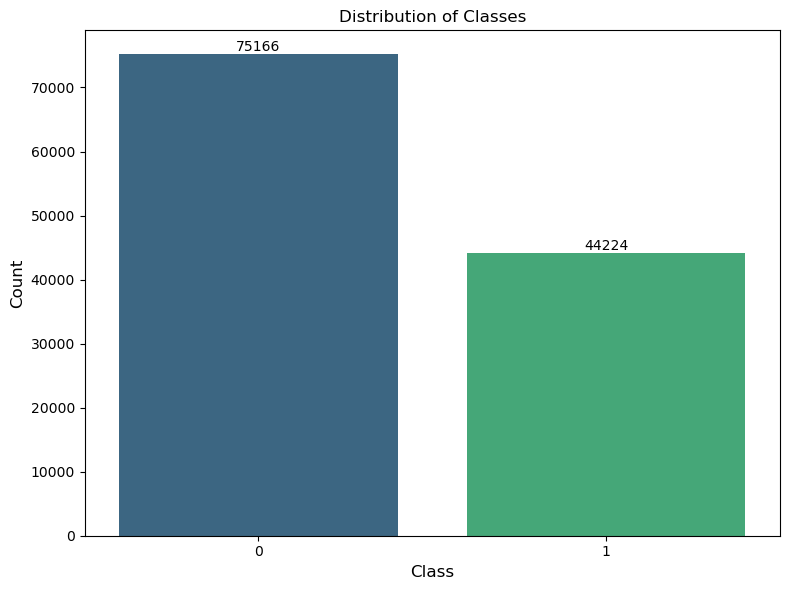

In [87]:
doTargetCountPlot(df_noshow, 'no_show')

In [88]:
cat_cols = doGetCatCols(df_noshow)

In [89]:
for i in range(len(cat_cols)):
    print(f"{cat_cols[i]} : {df_noshow[cat_cols[i]].unique()}")

branch : ['Changi' 'Orchard']
booking_month : ['November' 'August' 'March' 'September' 'July' 'January' 'October' 'June'
 'December' 'April' 'May' 'February']
arrival_month : ['June' 'November' 'February' 'October' 'September' 'March' 'May' 'August'
 'July' 'January' 'April' 'December']
arrival_day : ['25' '28' '07' '01' '20' '12' '15' '18' '27' '22' '09' '11' '10' '13'
 '30' '21' '05' '06' '02' '31' '19' '04' '03' '23' '17' '08' '26' '14'
 '24' '29' '16']
checkout_month : ['June' 'November' 'February' 'October' 'September' 'March' 'May' 'August'
 'July' 'January' 'April' 'December']
checkout_day : ['27' '29' '11' '03' '24' '13' '16' '19' '28' '10' '12' '15' '23' '31'
 '25' '17' '08' '02' '09' '07' '01' '20' '14' '4' '04' '06' '21' '05' '18'
 '22' '3' '30' '26' '6' '5' '8' '1' '7' '9' '2']
country : ['Singapore' 'Indonesia' 'India' 'China' 'Australia' 'Japan' 'Malaysia']
first_time : ['Yes' 'No']
room : ['Single' 'King' 'Queen' None 'President Suite']
platform : ['Website' 'Agent' 'Ema

In [90]:
num_cols = doGetNumericalCols(df_noshow)

In [91]:
num_cols

['booking_id',
 'no_show',
 'price',
 'num_adults',
 'num_children',
 'checkout',
 'checkin',
 'days_stayed']

### Univariate Analysis - Numerical

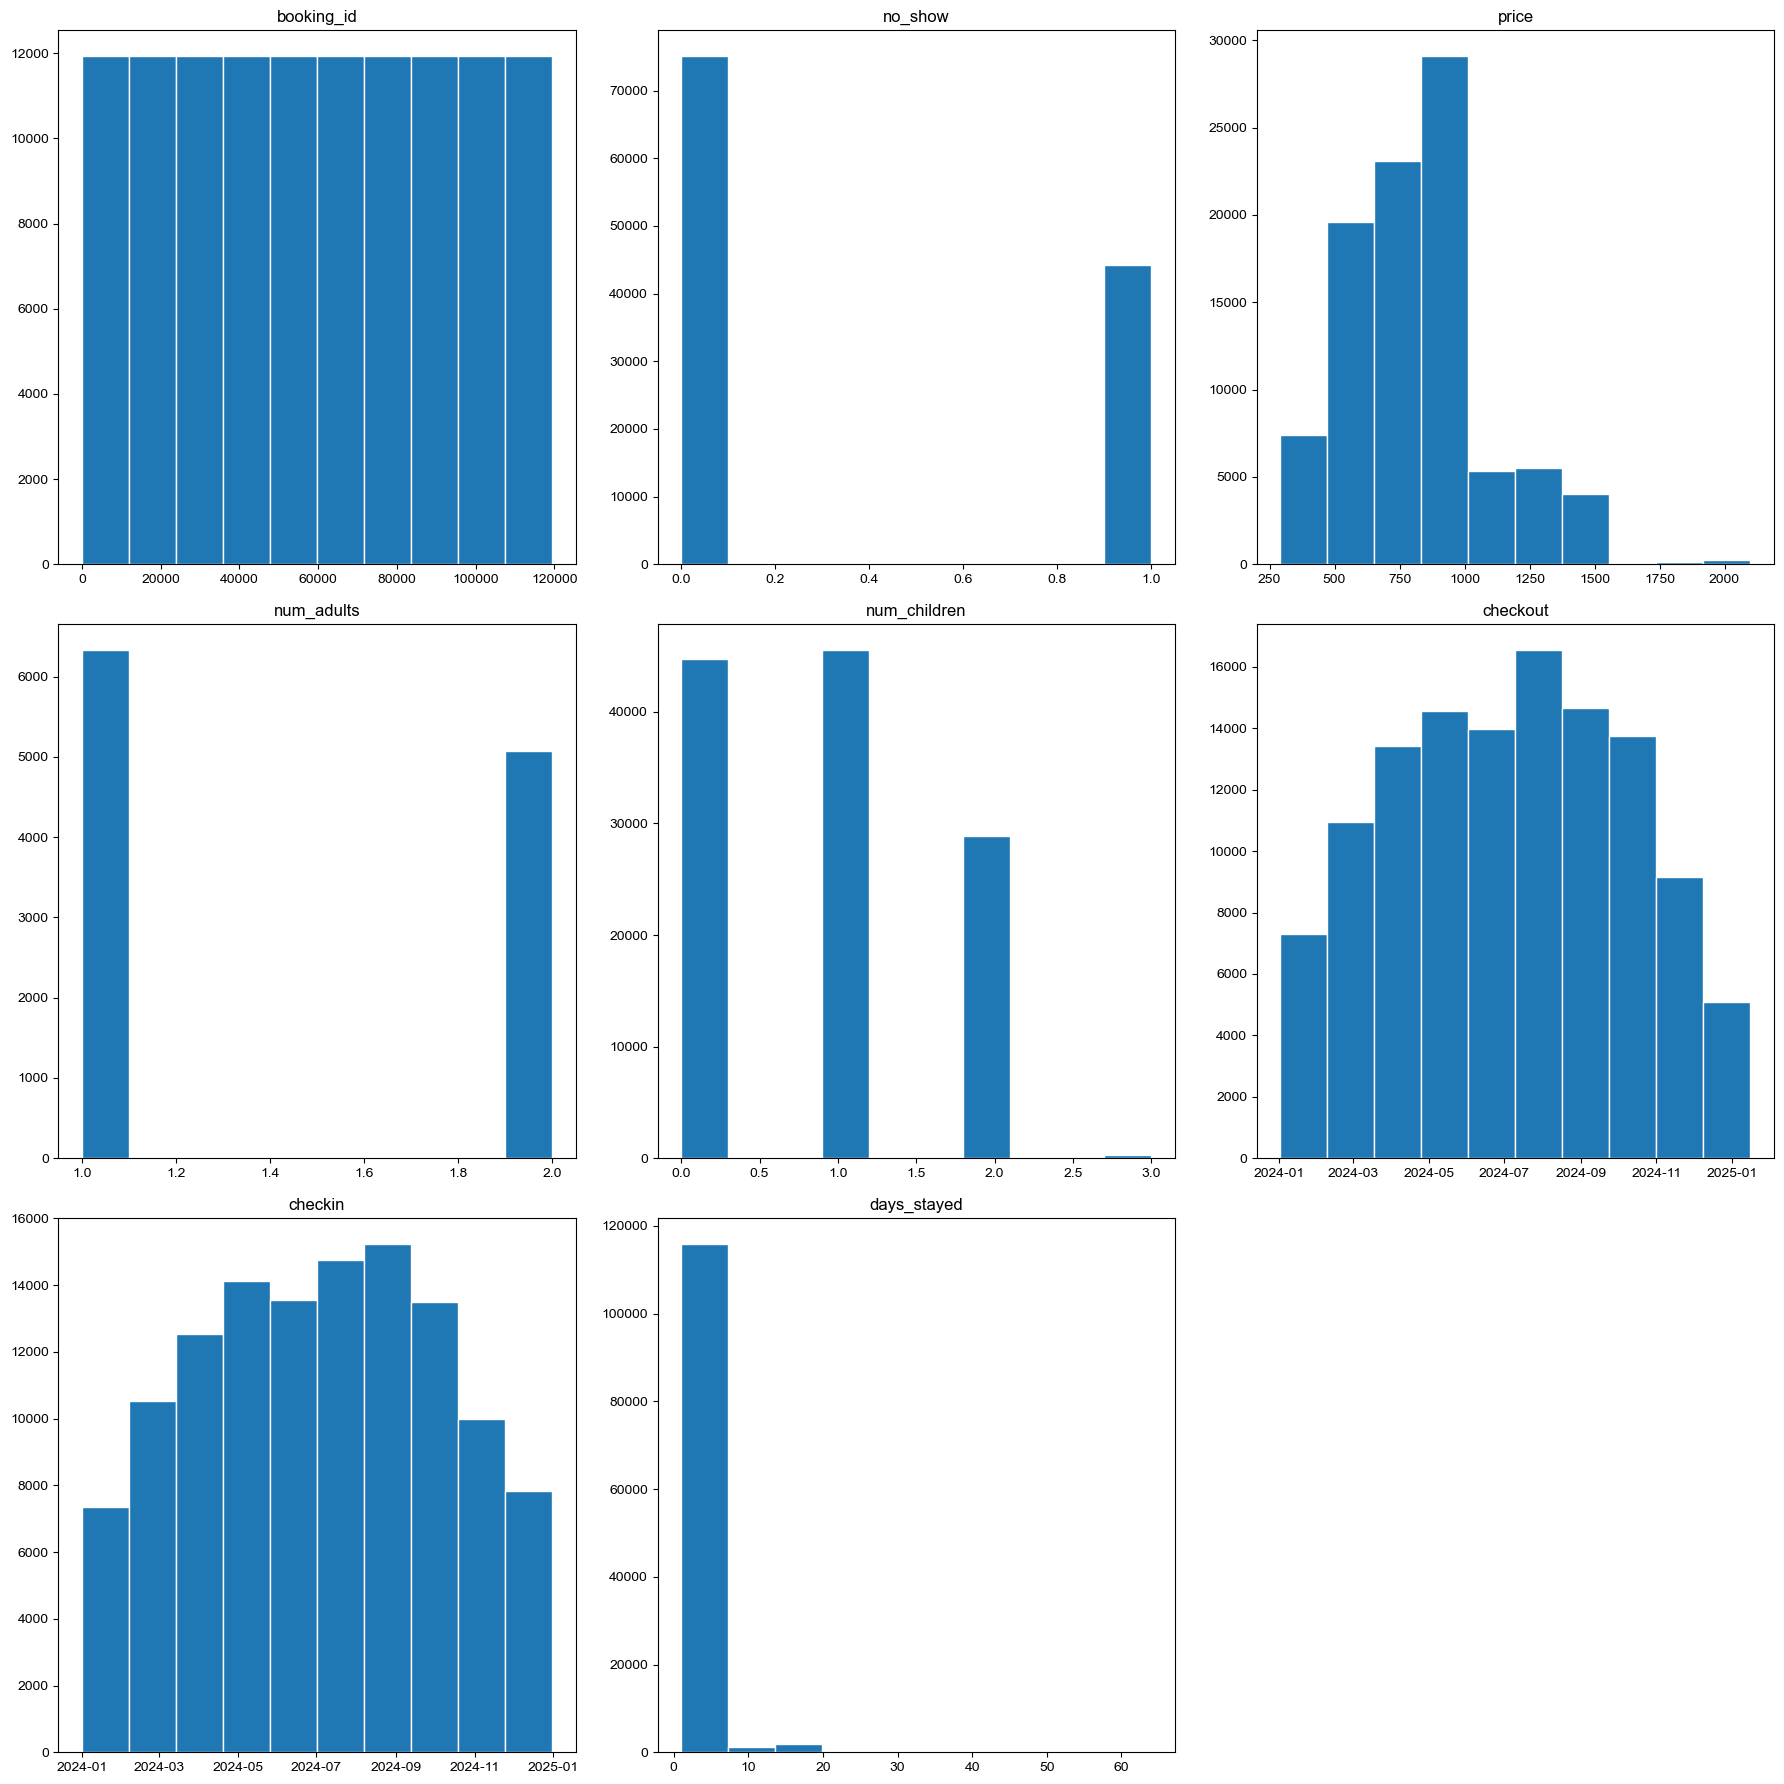

In [92]:
doHistogramPlots(df_noshow, num_cols)

### Univariate Analysis - Categorical

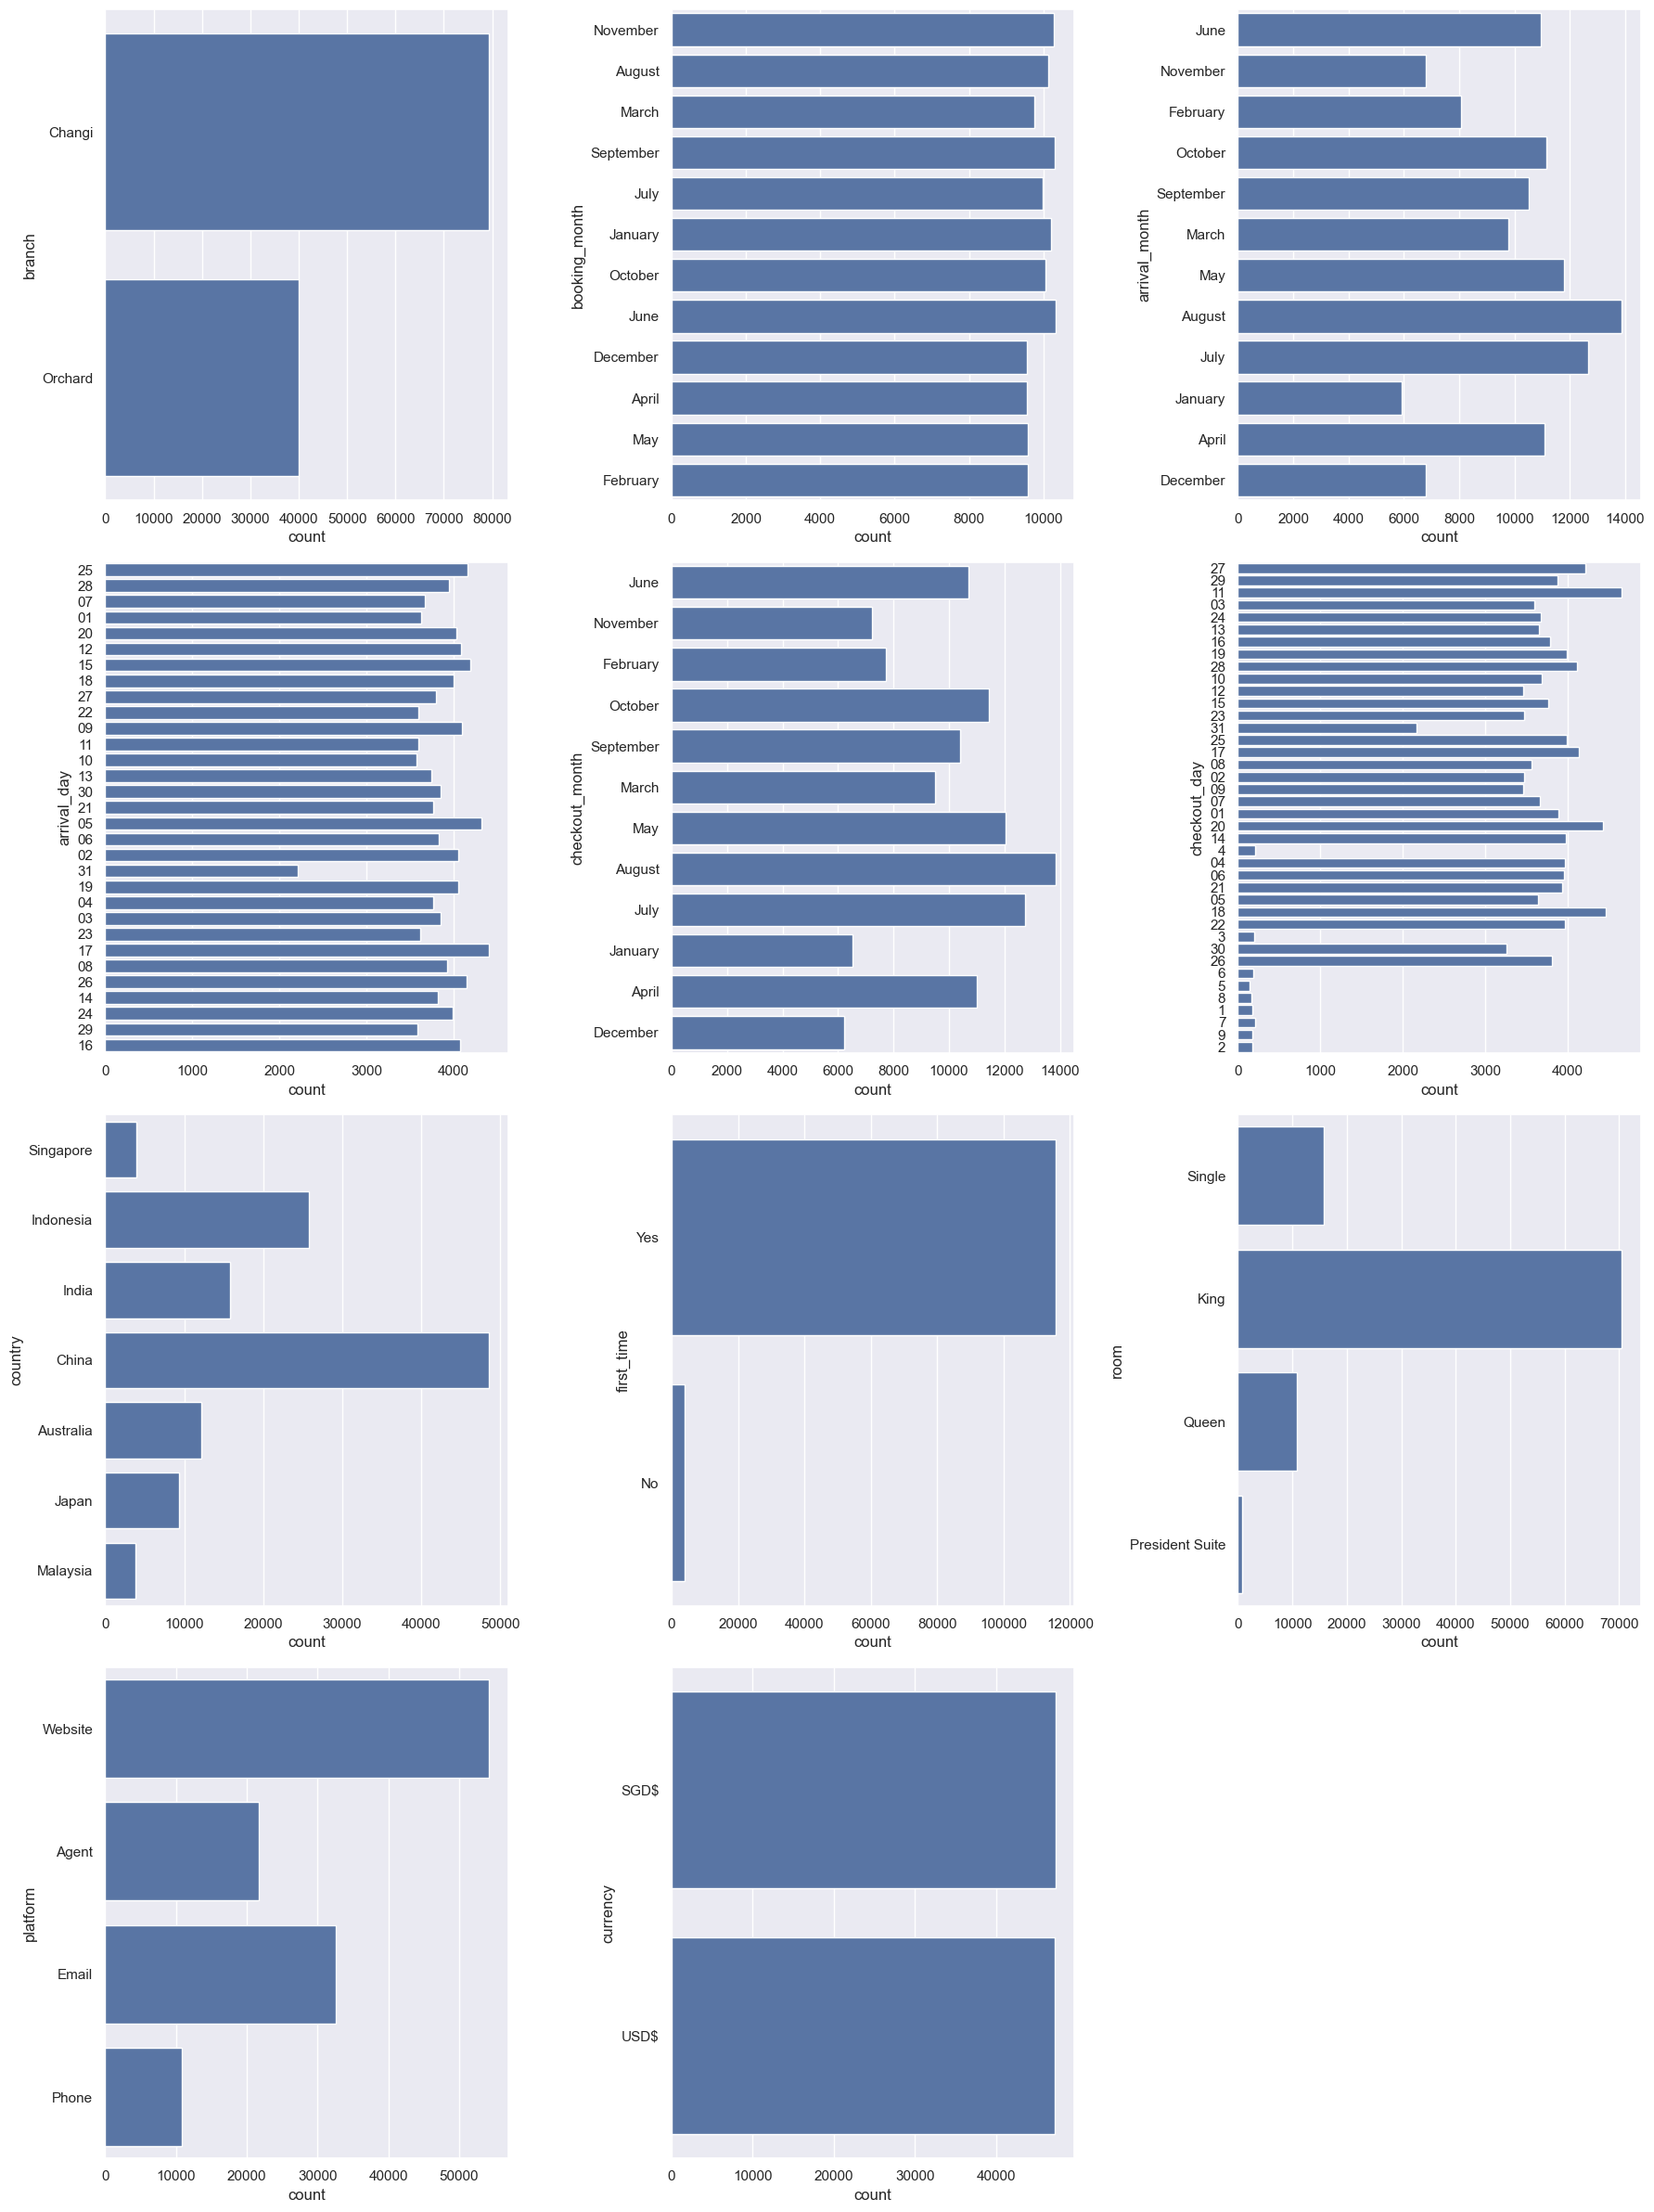

In [93]:
doCountPlots(df_noshow, cat_cols)

### Bivariate Analysis - Numerical vs Numerical

In [94]:
num_cols_1 = [
 'price',
 'num_adults',
 'num_children',
 'days_stayed']

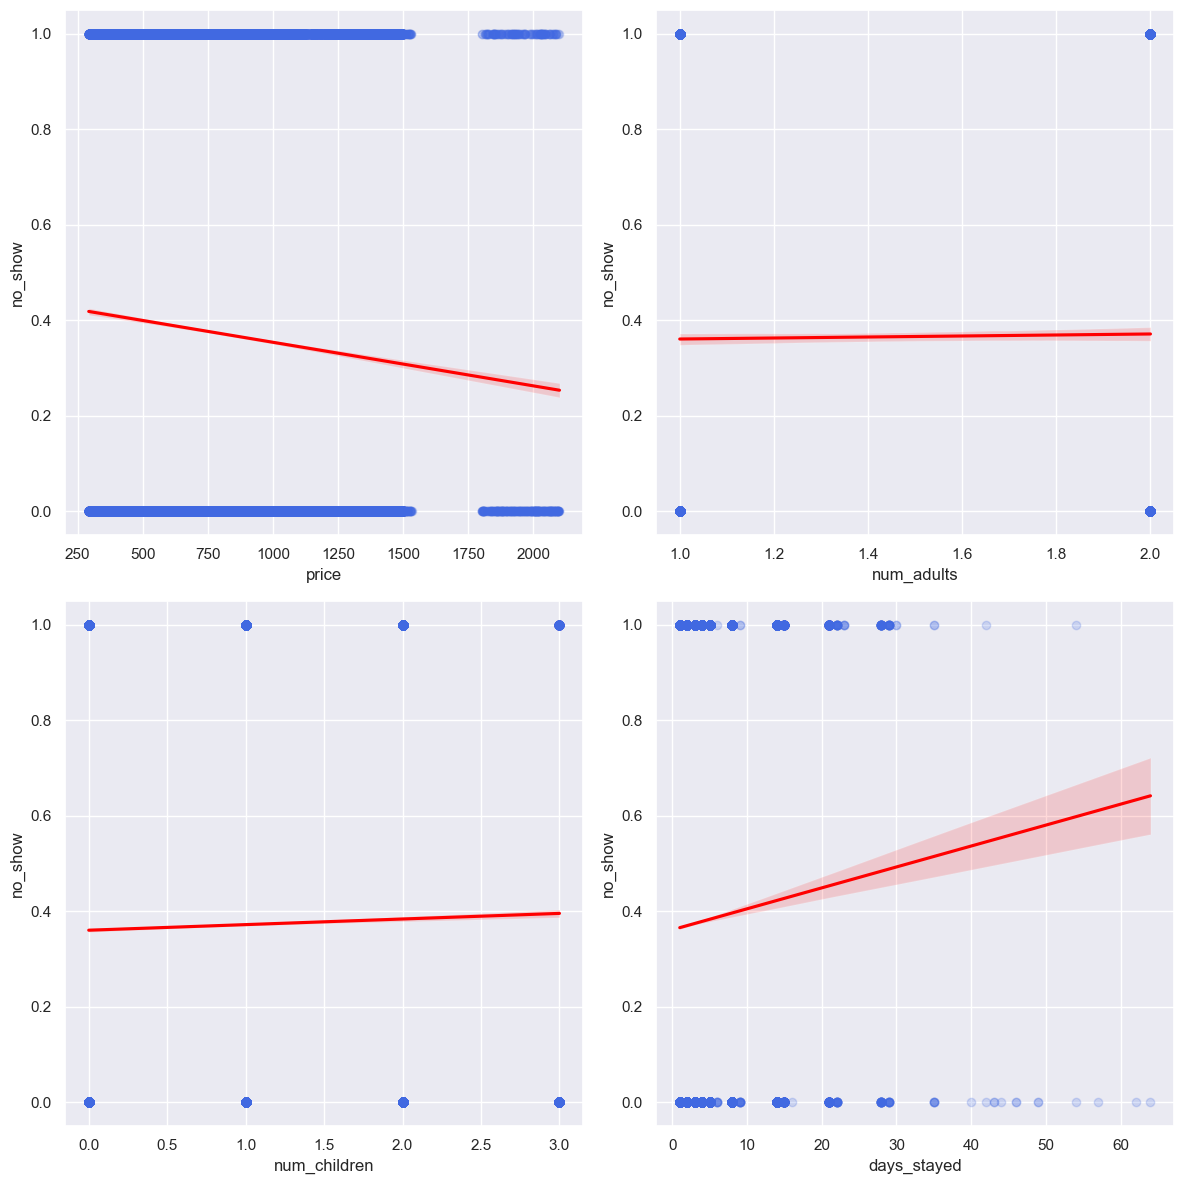

In [95]:
doRegPlots(df_noshow, num_cols_1, 'no_show')

### Bivariate Analysis - Categorical vs Categorical

In [96]:
cat_cols

['branch',
 'booking_month',
 'arrival_month',
 'arrival_day',
 'checkout_month',
 'checkout_day',
 'country',
 'first_time',
 'room',
 'platform',
 'currency']

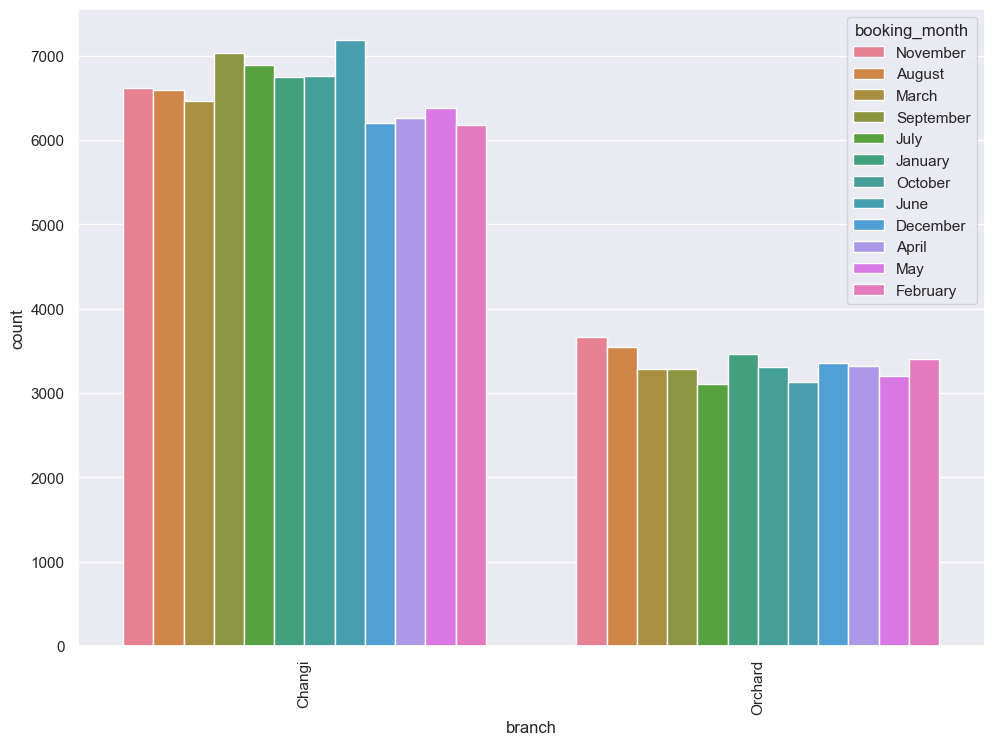

In [97]:
ax = sns.countplot(df_noshow, x="branch", hue="booking_month")
ax.tick_params(axis='x', rotation=90)

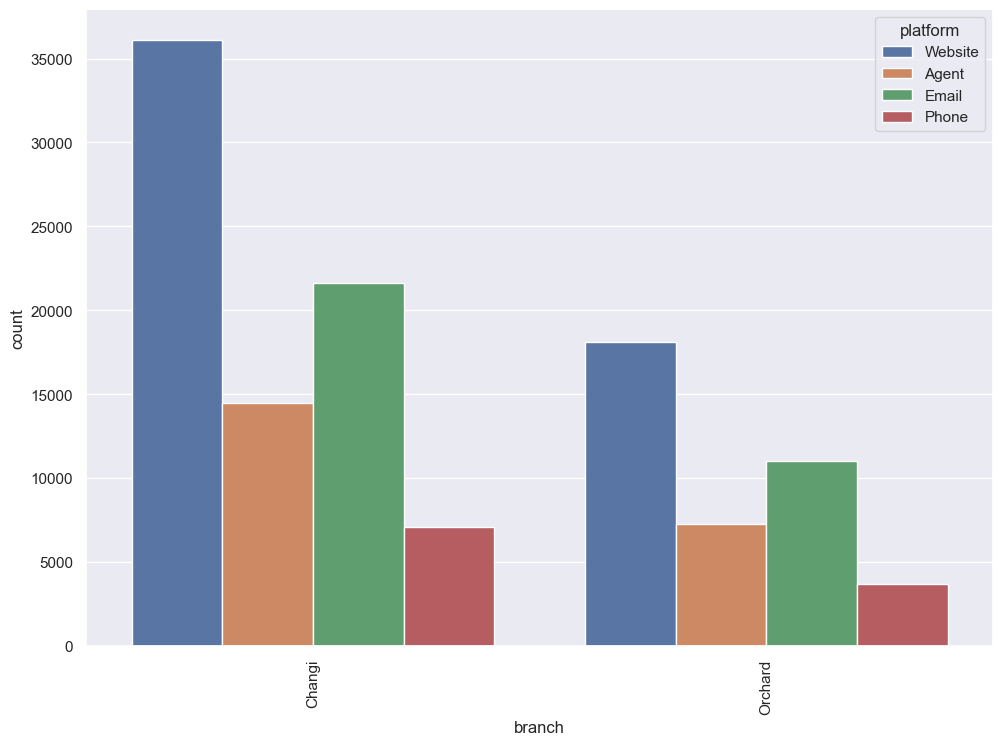

In [98]:
ax = sns.countplot(df_noshow, x="branch", hue="platform")
ax.tick_params(axis='x', rotation=90)

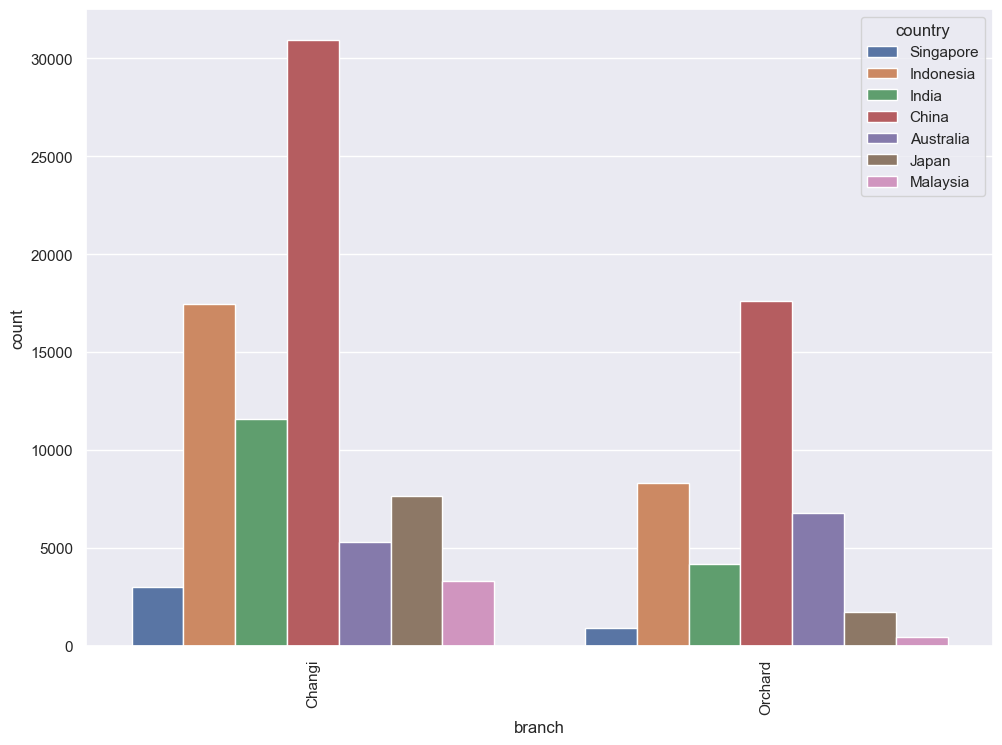

In [99]:
ax = sns.countplot(df_noshow, x="branch", hue="country")
ax.tick_params(axis='x', rotation=90)

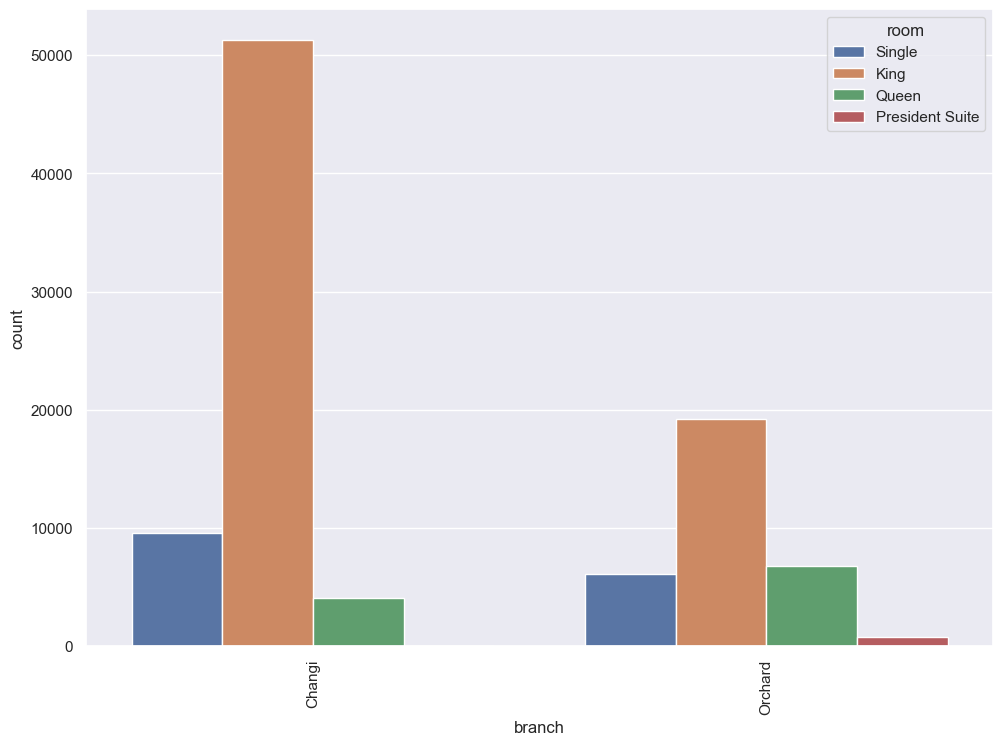

In [100]:
ax = sns.countplot(df_noshow, x="branch", hue="room")
ax.tick_params(axis='x', rotation=90)

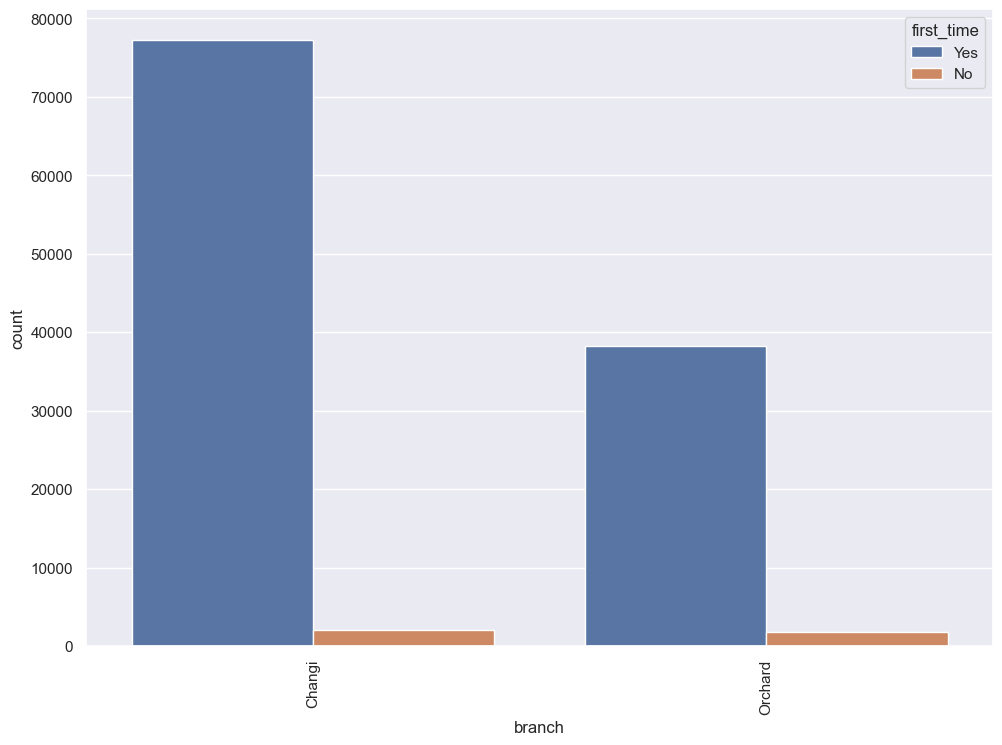

In [101]:
ax = sns.countplot(df_noshow, x="branch", hue="first_time")
ax.tick_params(axis='x', rotation=90)

### Bivariate Analysis - Numerical vs Categorical

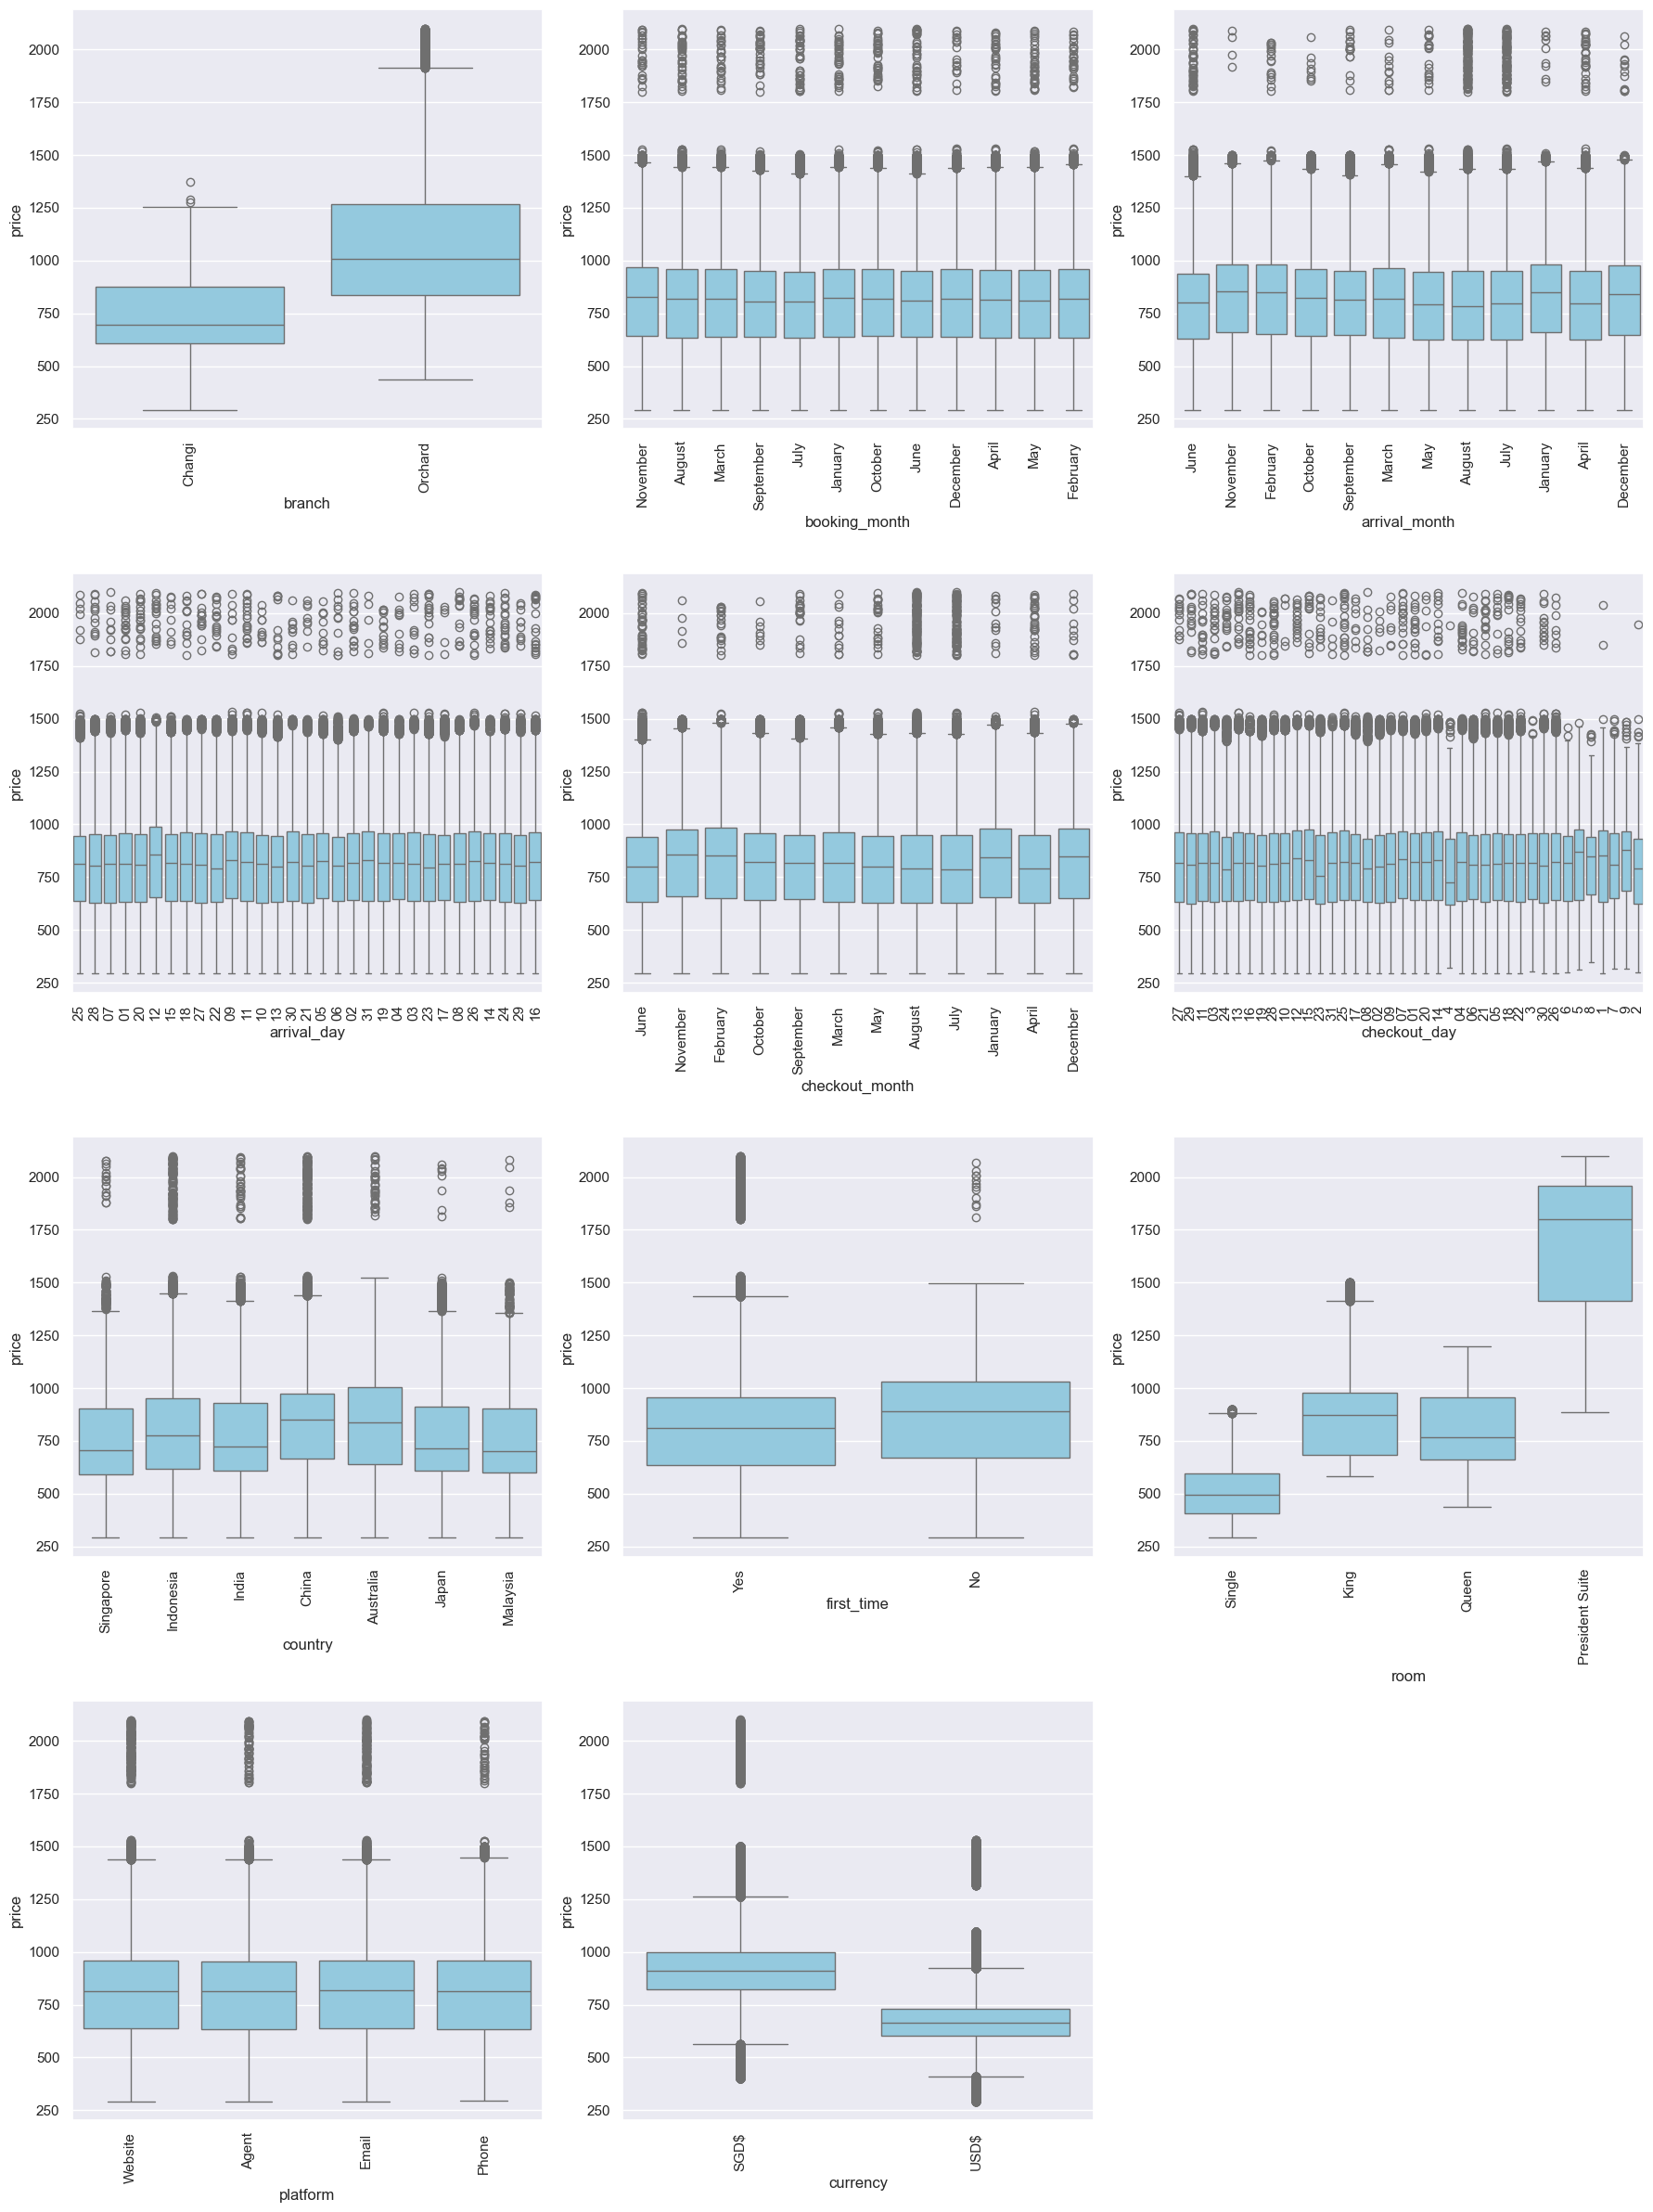

In [102]:
doBoxPlots(df_noshow, cat_cols, 'b', 'price')

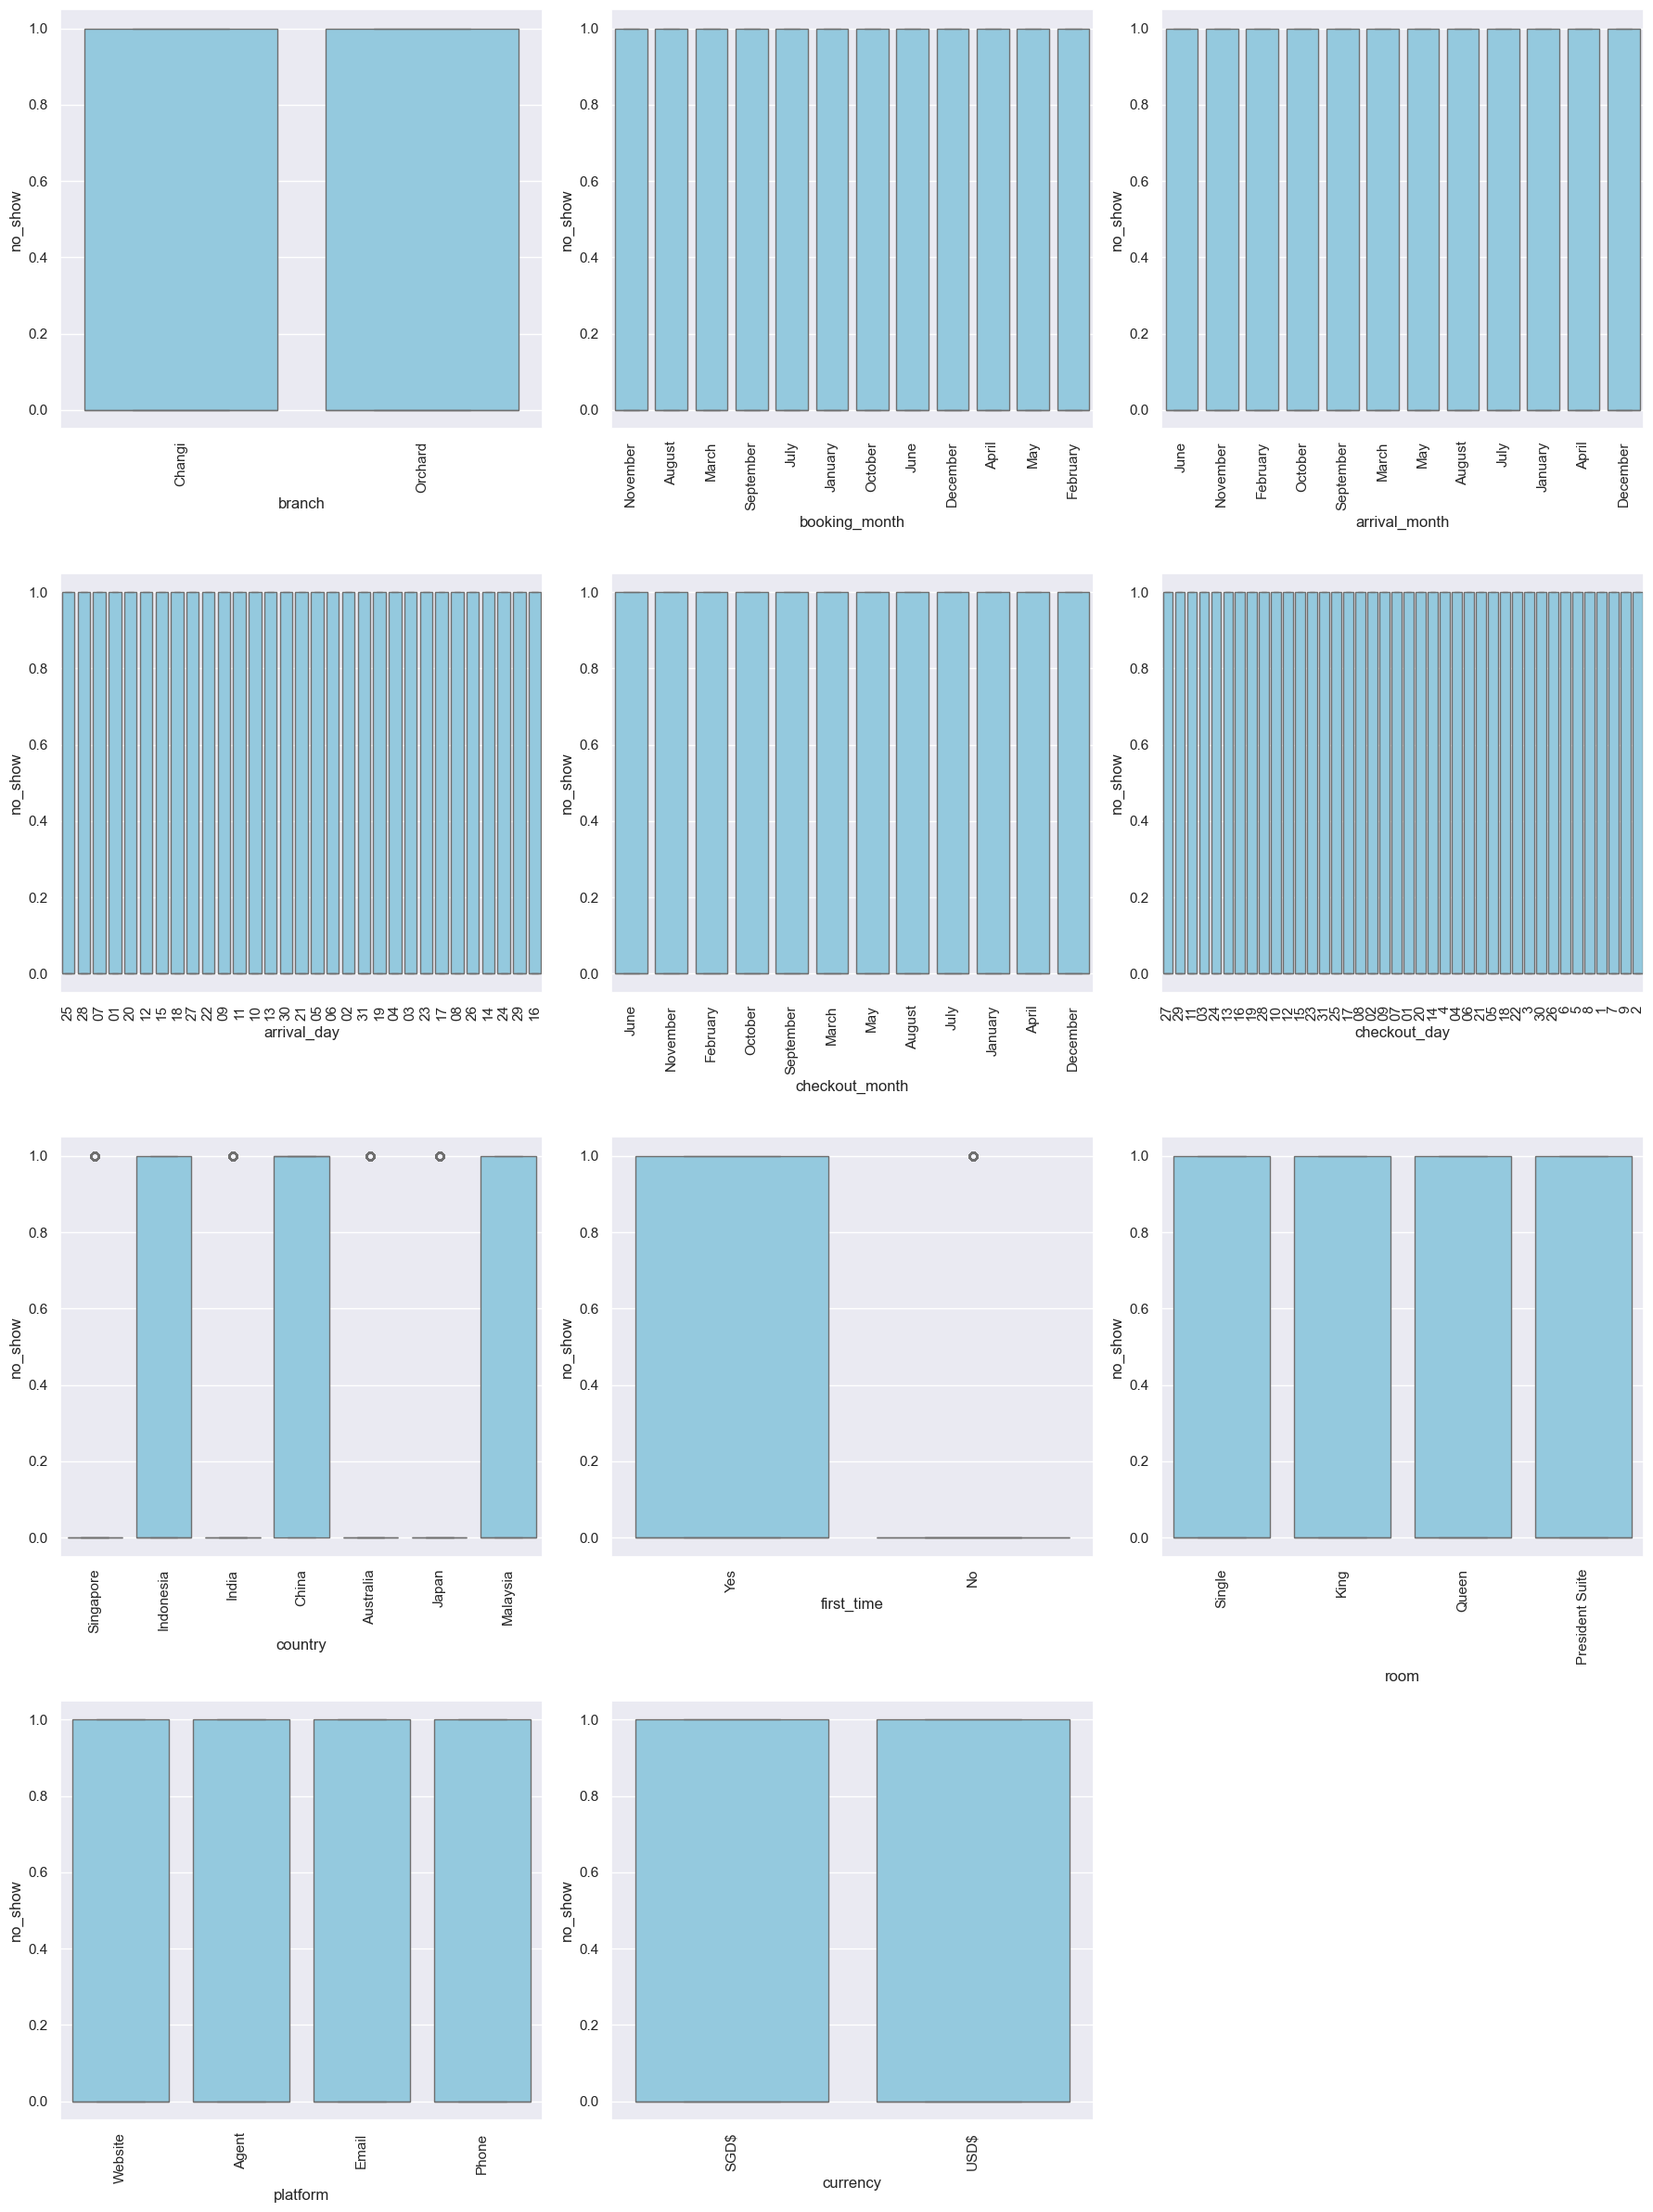

In [103]:
doBoxPlots(df_noshow, cat_cols, 'b', 'no_show')

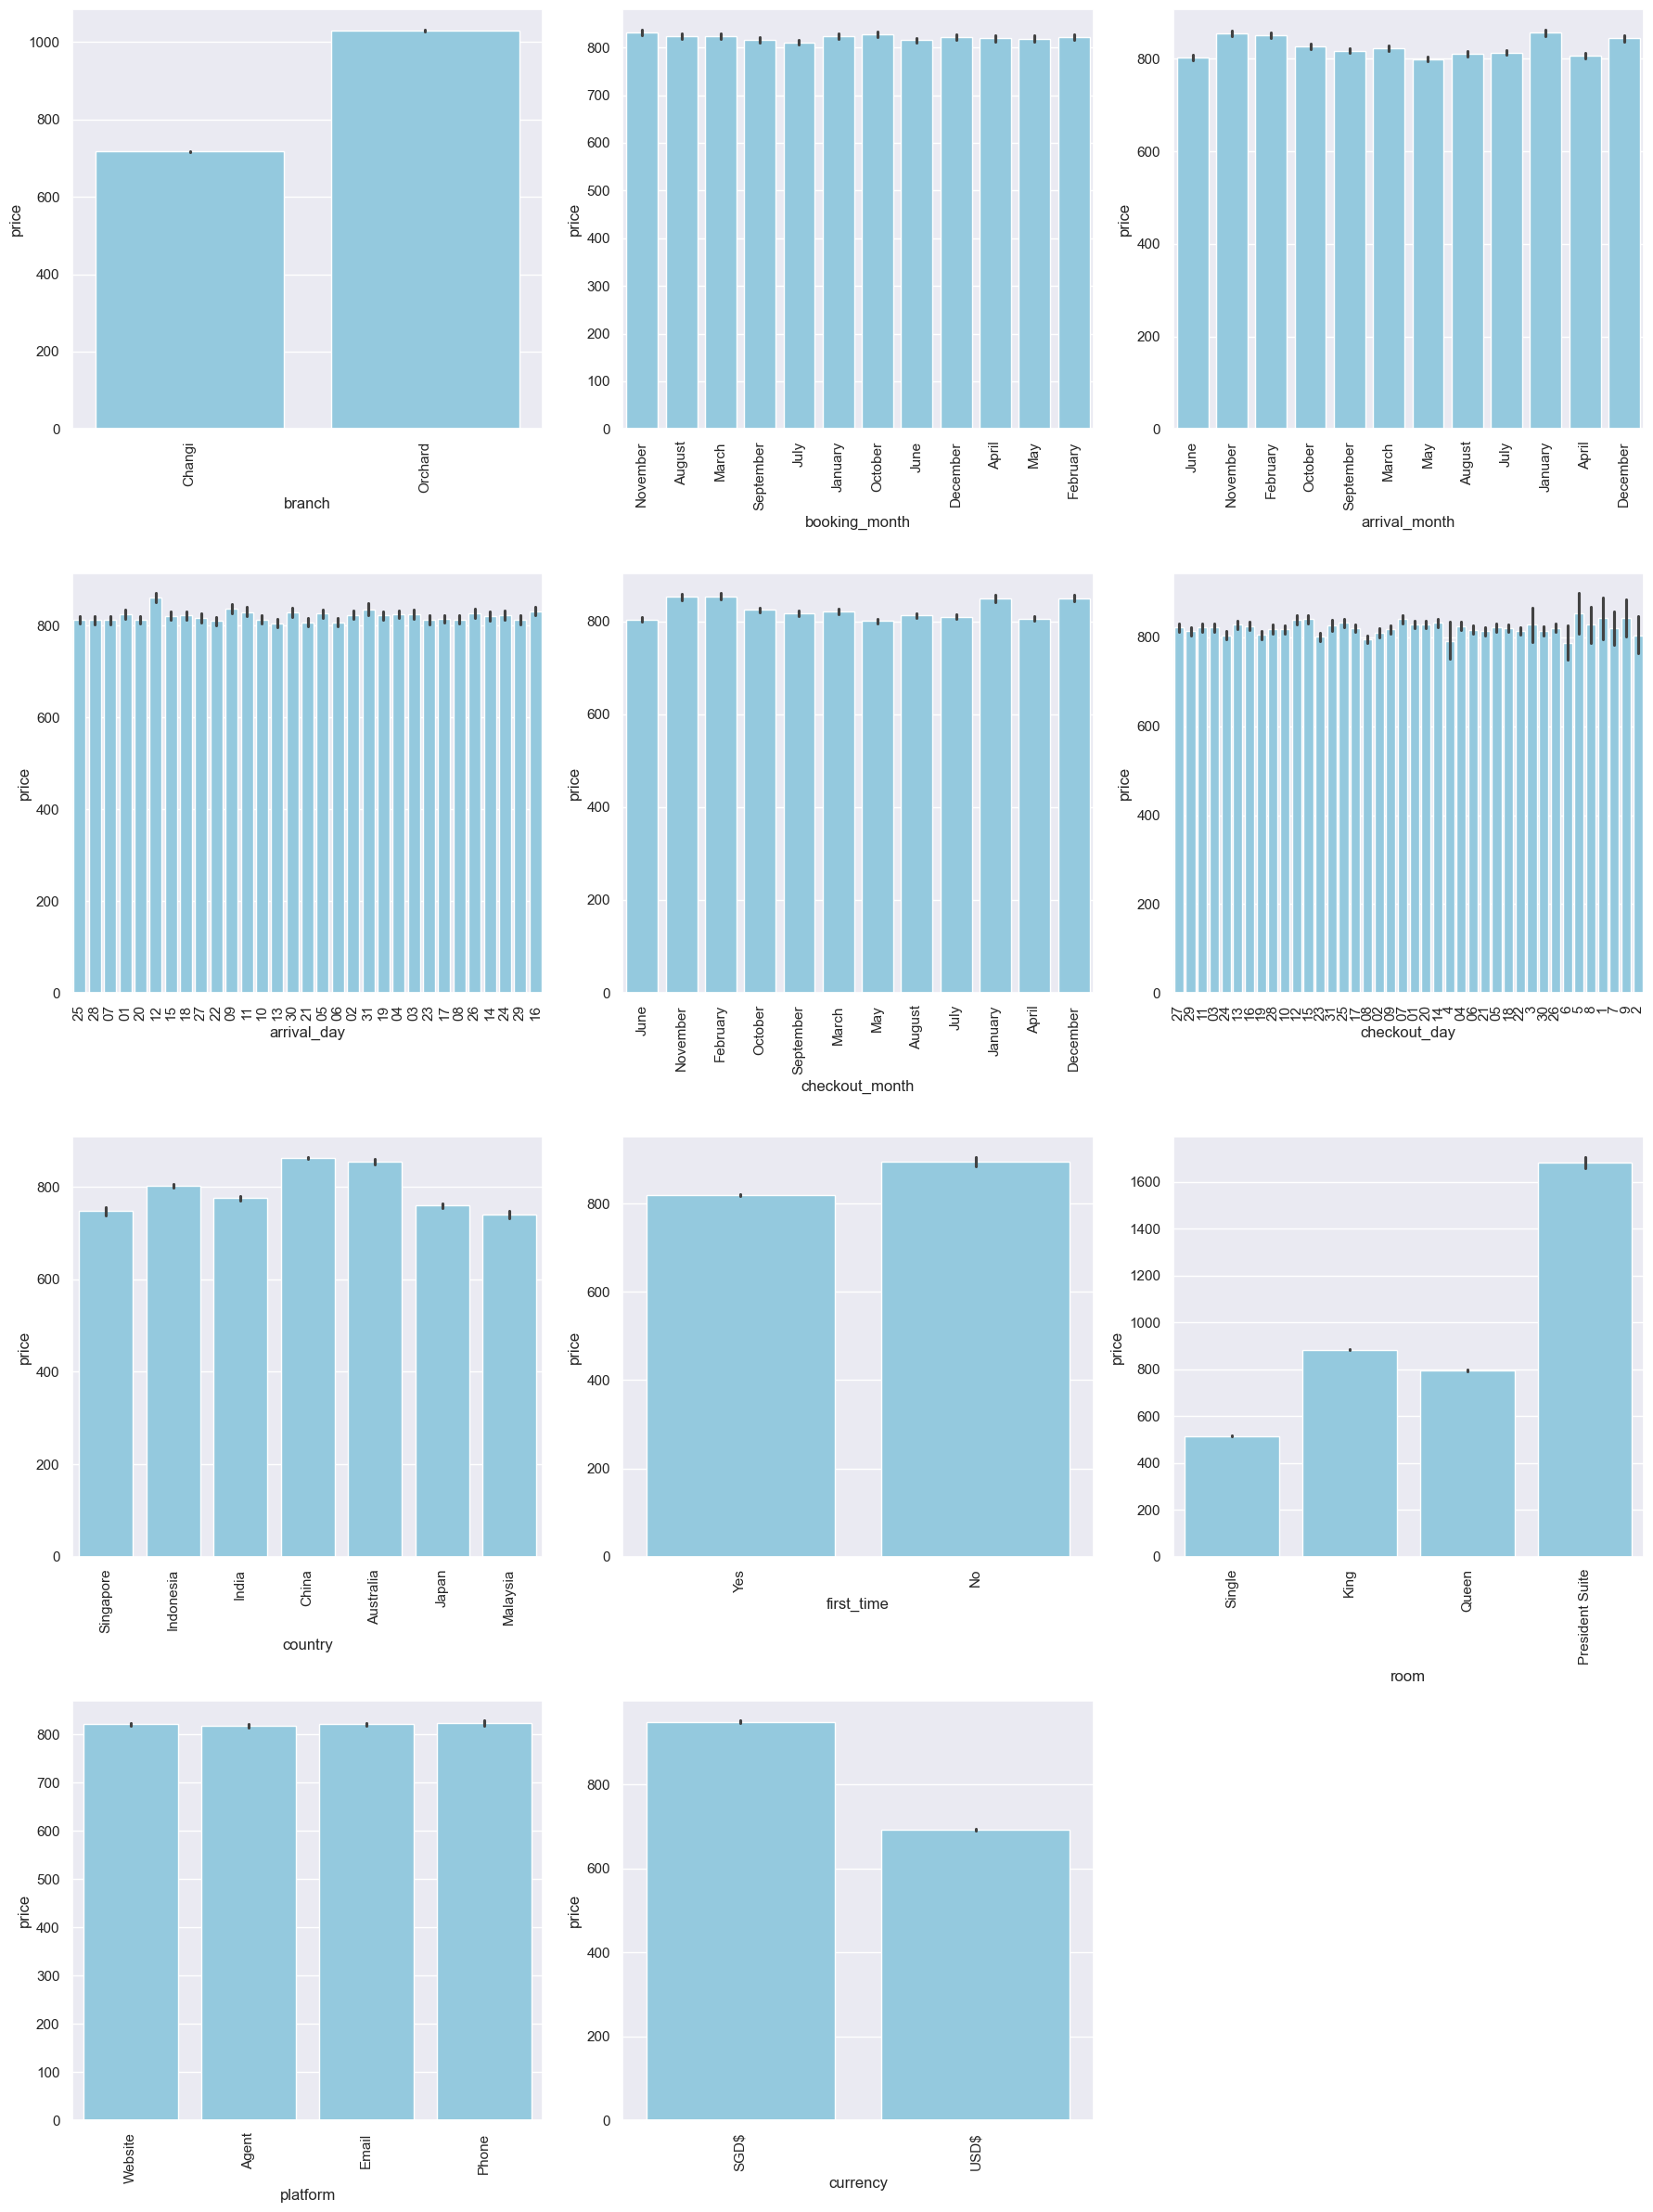

In [104]:
doBarPlots(df_noshow, cat_cols, 'price')

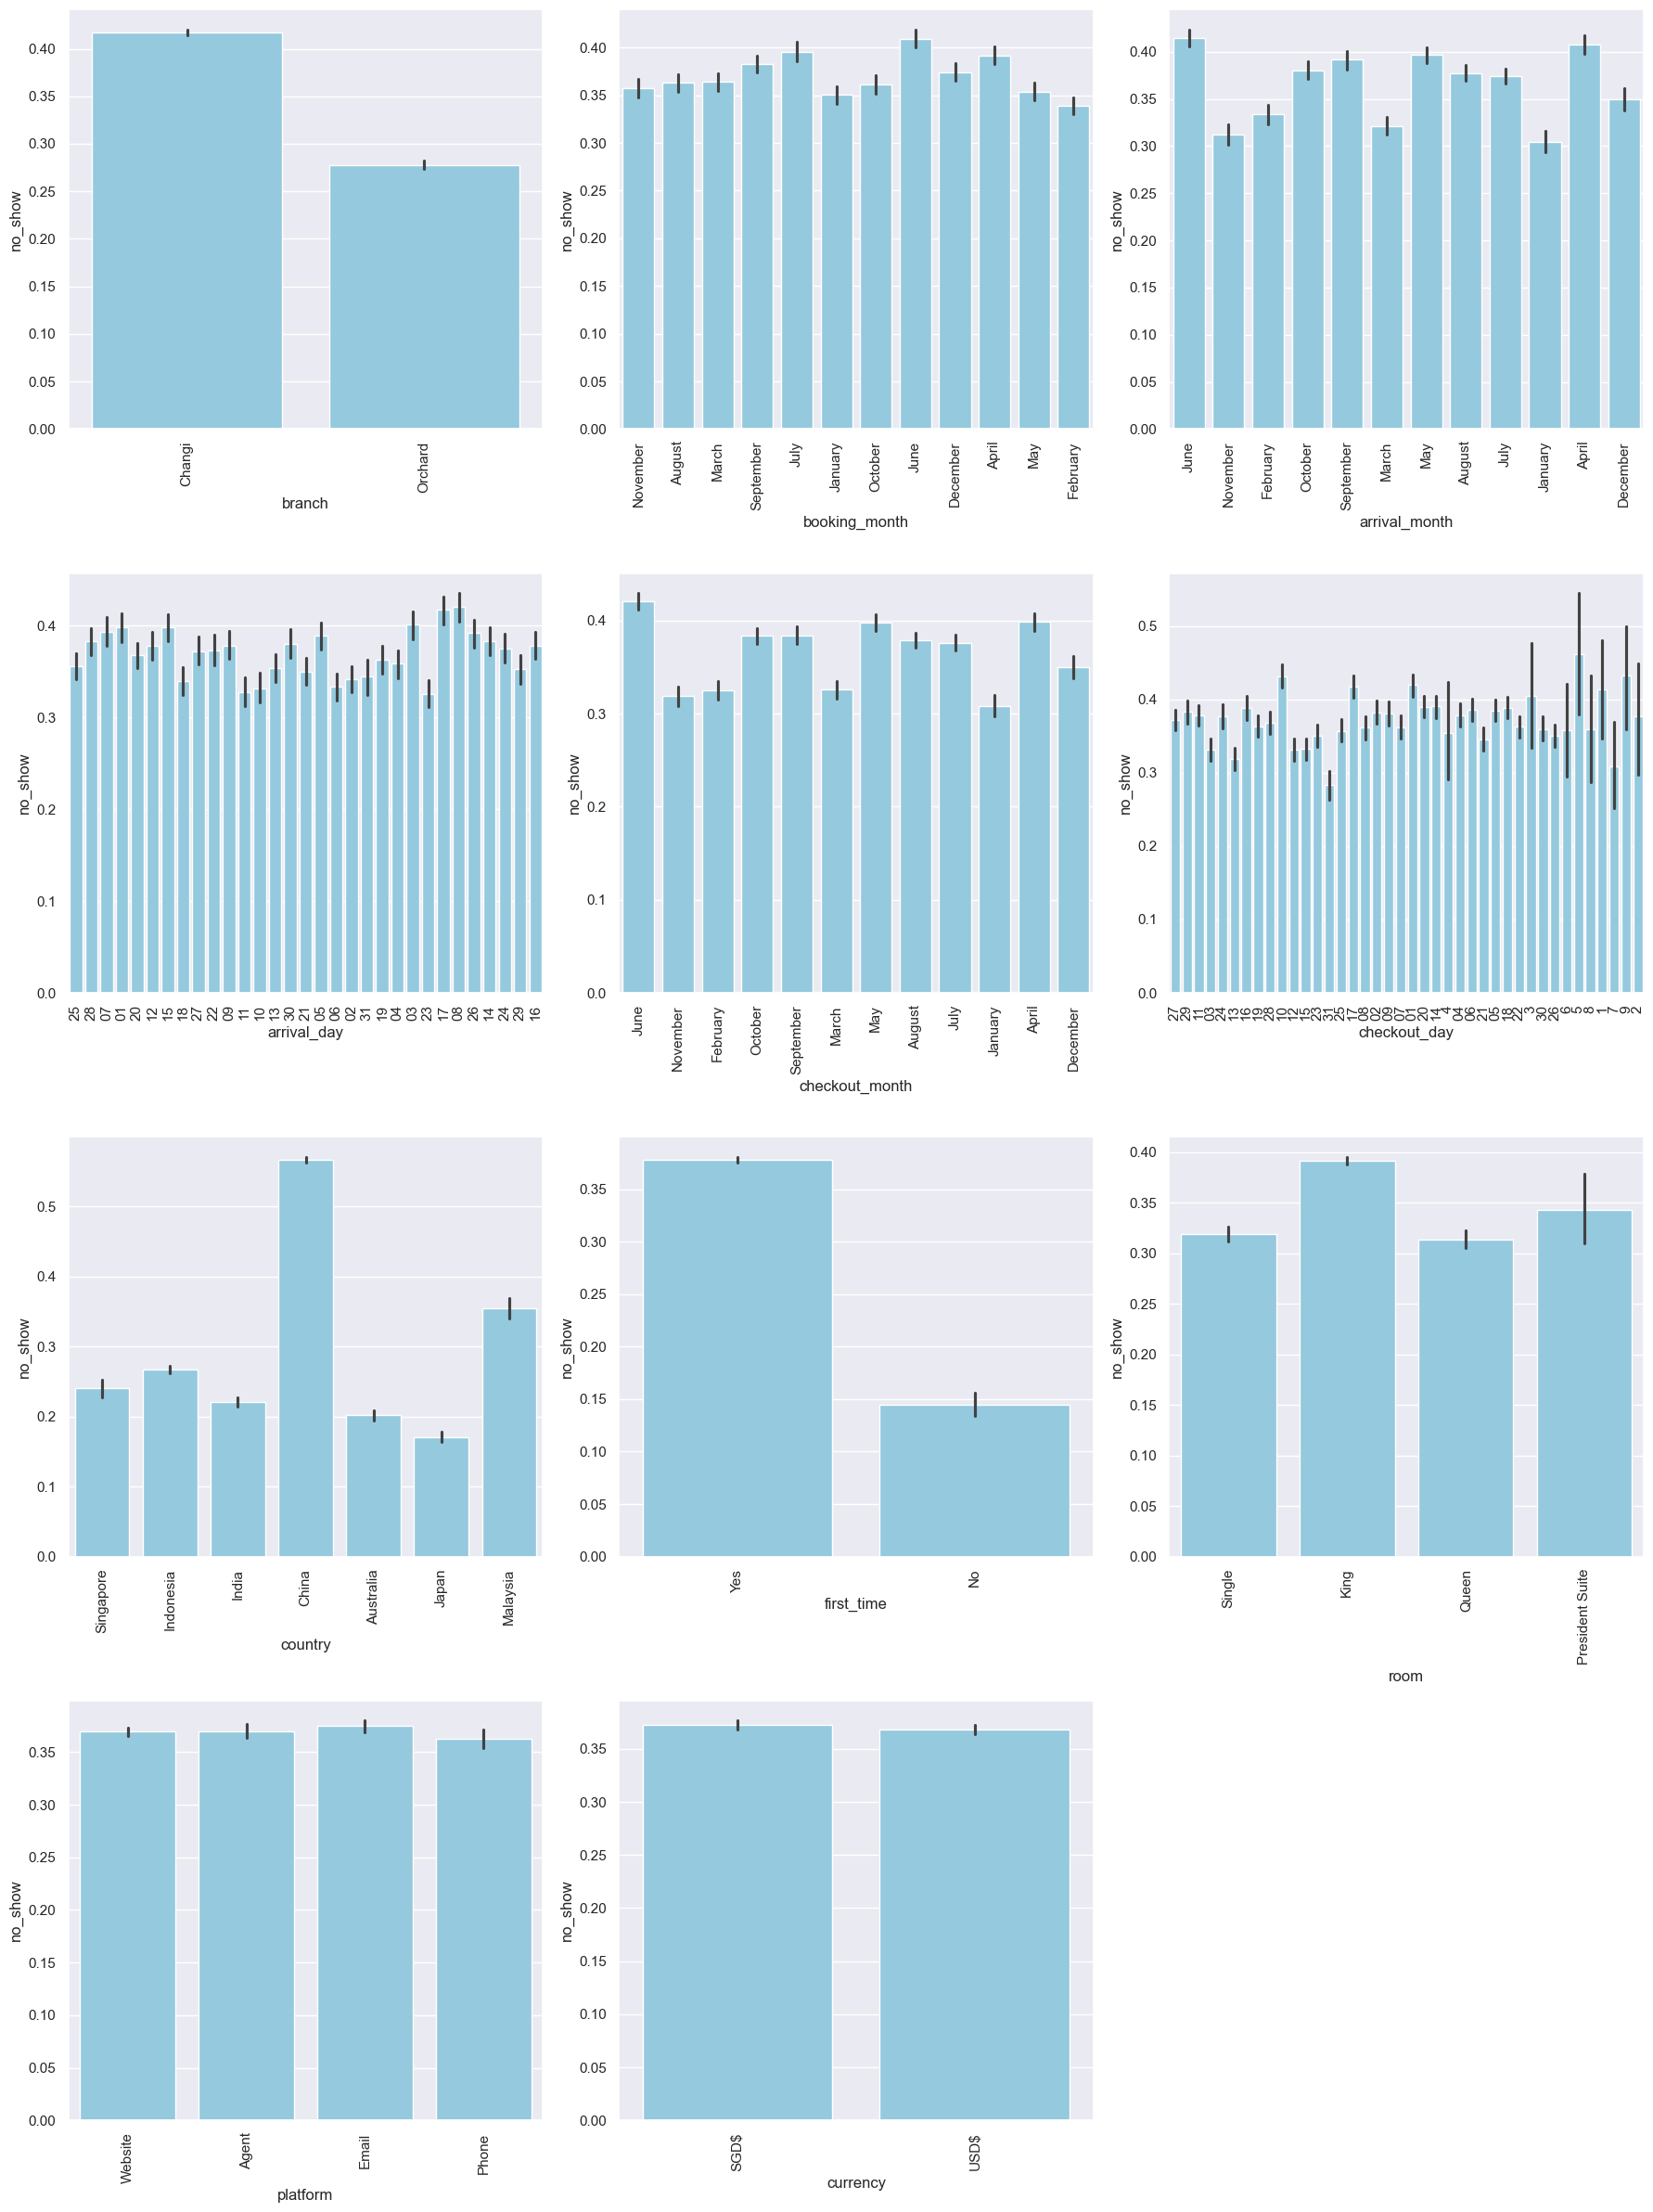

In [105]:
doBarPlots(df_noshow, cat_cols, 'no_show')

### Multivariate analysis

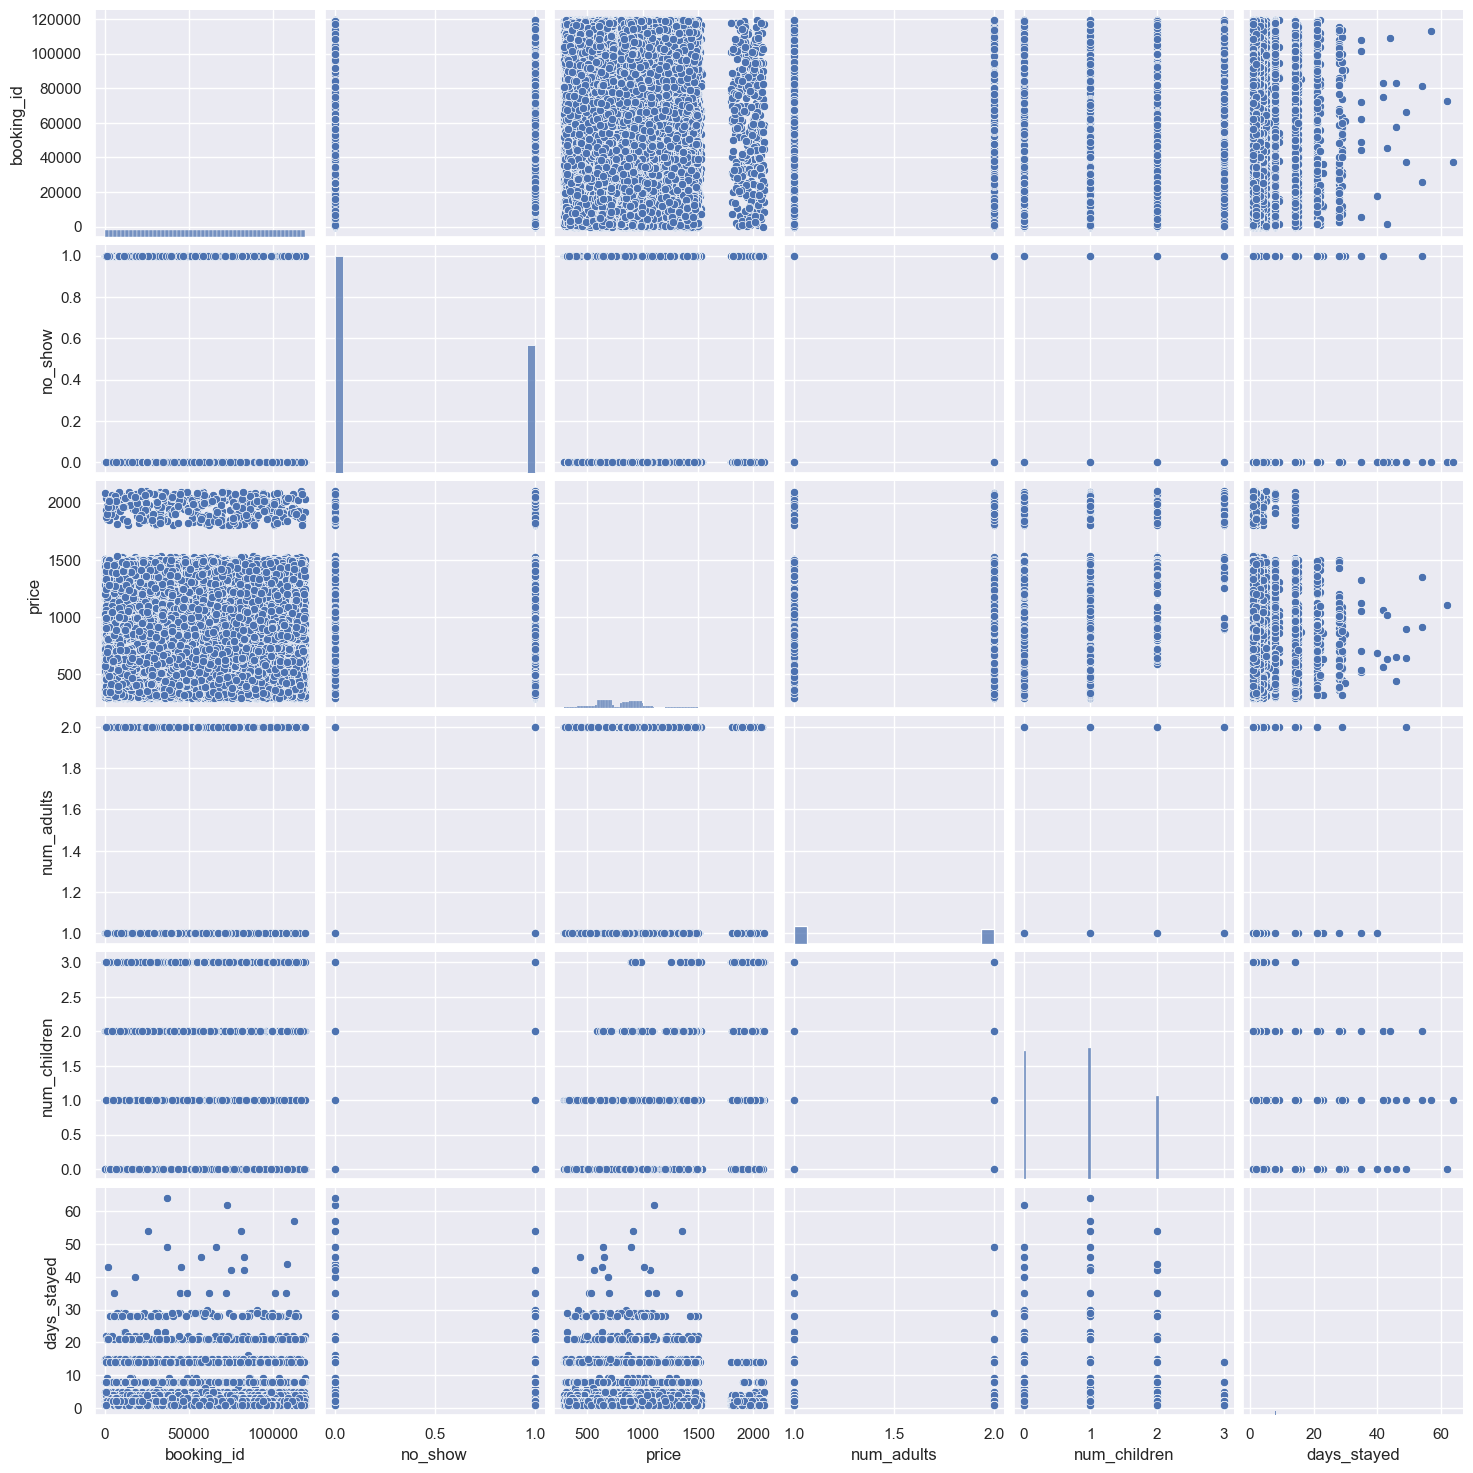

In [106]:
sns.pairplot(df_noshow)

In [107]:
# doPairPlots(df_noshow, cat_cols)

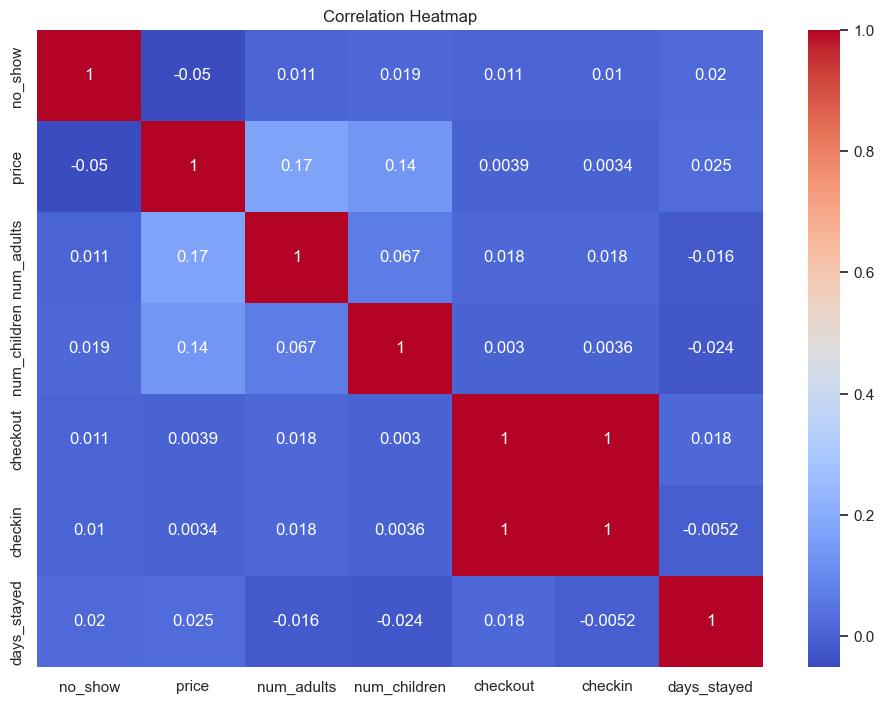

In [108]:
doHeatMapPlots(df_noshow, num_cols[1:], 'no_show')

# Data pre-processing

In [109]:
df_noshow.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119390 entries, 0 to 119390
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   booking_id      119390 non-null  int64         
 1   no_show         119390 non-null  int32         
 2   branch          119390 non-null  object        
 3   booking_month   119390 non-null  object        
 4   arrival_month   119390 non-null  object        
 5   arrival_day     119390 non-null  object        
 6   checkout_month  119390 non-null  object        
 7   checkout_day    119390 non-null  object        
 8   country         119390 non-null  object        
 9   first_time      119390 non-null  object        
 10  room            97778 non-null   object        
 11  price           94509 non-null   float64       
 12  platform        119390 non-null  object        
 13  num_adults      11402 non-null   float64       
 14  num_children    119390 non-null  float64 

In [110]:
df_noshow.drop(['booking_id', 'no_show', 'booking_month', 'arrival_month', 'arrival_day', 'checkout_month', 'checkout_day', 'checkout', 'checkin'], axis=1)

,branch,country,first_time,room,price,platform,num_adults,num_children,currency,days_stayed
0,Changi,Singapore,Yes,Single,492.98,Website,NaN,0.0,SGD$,2
1,Orchard,Indonesia,Yes,King,1351.22,Website,NaN,0.0,SGD$,1
2,Changi,India,Yes,Single,NaN,Agent,NaN,0.0,None,4
3,Orchard,China,Yes,Single,666.04,Website,NaN,0.0,SGD$,2
4,Orchard,Australia,Yes,Queen,665.37,Website,NaN,0.0,USD$,4
...,...,...,...,...,...,...,...,...,...,...
119386,Changi,China,Yes,King,612.18,Website,NaN,1.0,USD$,2
119387,Orchard,China,Yes,King,1041.29,Email,NaN,0.0,USD$,4
119388,Changi,Indonesia,Yes,King,641.47,Email,NaN,2.0,USD$,1
119389,Changi,China,Yes,None,886.35,Website,NaN,0.0,SGD$,2


In [111]:
# X_train, X_test, y_train, y_test = train_test_split(df_noshow.drop(['booking_id', 'no_show', 'booking_month', 'arrival_month', 'arrival_day', 'checkout_month', 'checkout_day', 'checkout', 'checkin'], axis=1), df_noshow['no_show'], test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(df_noshow.drop(['booking_id', 'no_show'], axis=1), df_noshow['no_show'], test_size=0.3, random_state=42)

X_train.shape, X_test.shape

((83573, 17), (35817, 17))

In [112]:
X_train.columns

Index(['branch', 'booking_month', 'arrival_month', 'arrival_day',
       'checkout_month', 'checkout_day', 'country', 'first_time', 'room',
       'price', 'platform', 'num_adults', 'num_children', 'currency',
       'checkout', 'checkin', 'days_stayed'],
      dtype='object')

In [113]:
X_train.columns

Index(['branch', 'booking_month', 'arrival_month', 'arrival_day',
       'checkout_month', 'checkout_day', 'country', 'first_time', 'room',
       'price', 'platform', 'num_adults', 'num_children', 'currency',
       'checkout', 'checkin', 'days_stayed'],
      dtype='object')

## Missing Value Imputation - Median

In [114]:
median_imputer = MeanMedianImputer(imputation_method='median',
                                   variables=['price', 'num_adults'])

median_imputer.fit(X_train)

,imputation_method,'median'
,variables,"['price', 'num_adults']"


In [115]:
median_imputer.imputer_dict_

{'price': 815.165, 'num_adults': 1.0}

In [116]:
# transform the data
X_train = median_imputer.transform(X_train)
X_test = median_imputer.transform(X_test)

In [117]:
# check that null values were replaced
X_train[['price', 'num_adults']].isnull().mean()

price         0.0
num_adults    0.0
dtype: float64

## Missing Value Imputation - Mode

In [118]:
mode_imputer = CategoricalImputer(
    imputation_method='frequent',
    variables=['currency', 'room']
)

mode_imputer.fit(X_train)

,imputation_method,'frequent'
,fill_value,'Missing'
,variables,"['currency', 'room']"
,return_object,False
,ignore_format,False


In [119]:
# dictionary with the mappings for each variable
mode_imputer.imputer_dict_

{'currency': 'SGD$', 'room': 'King'}

In [120]:
X_train = mode_imputer.transform(X_train)
X_test = mode_imputer.transform(X_test)

In [121]:
X_train[['currency', 'price']].isnull().mean()

currency    0.0
price       0.0
dtype: float64

In [122]:
doFindRowsWithNoneInColumn(X_train, 'currency')

,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,currency,checkout,checkin,days_stayed


In [123]:
X_train.columns

Index(['branch', 'booking_month', 'arrival_month', 'arrival_day',
       'checkout_month', 'checkout_day', 'country', 'first_time', 'room',
       'price', 'platform', 'num_adults', 'num_children', 'currency',
       'checkout', 'checkin', 'days_stayed'],
      dtype='object')

In [124]:
X_test.isnull().sum()

branch            0
booking_month     0
arrival_month     0
arrival_day       0
checkout_month    0
checkout_day      0
country           0
first_time        0
room              0
price             0
platform          0
num_adults        0
num_children      0
currency          0
checkout          0
checkin           0
days_stayed       0
dtype: int64

## Categorical data encoding - OHE

In [125]:
doGetCatCols(X_train)

['branch',
 'booking_month',
 'arrival_month',
 'arrival_day',
 'checkout_month',
 'checkout_day',
 'country',
 'first_time',
 'room',
 'platform',
 'currency']

In [126]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83573 entries, 9710 to 15795
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   branch          83573 non-null  object        
 1   booking_month   83573 non-null  object        
 2   arrival_month   83573 non-null  object        
 3   arrival_day     83573 non-null  object        
 4   checkout_month  83573 non-null  object        
 5   checkout_day    83573 non-null  object        
 6   country         83573 non-null  object        
 7   first_time      83573 non-null  object        
 8   room            83573 non-null  object        
 9   price           83573 non-null  float64       
 10  platform        83573 non-null  object        
 11  num_adults      83573 non-null  float64       
 12  num_children    83573 non-null  float64       
 13  currency        83573 non-null  object        
 14  checkout        83573 non-null  datetime64[ns]
 15  chec

In [127]:
doCountUniqueCategories(X_train, doGetCatCols(X_train))

branch # 2: ['Changi' 'Orchard']
booking_month # 12: ['October' 'December' 'January' 'July' 'March' 'February' 'May' 'June'
 'August' 'November' 'September' 'April']
arrival_month # 12: ['August' 'July' 'March' 'June' 'October' 'May' 'January' 'November'
 'April' 'February' 'December' 'September']
arrival_day # 31: ['05' '18' '20' '13' '02' '09' '16' '14' '04' '23' '19' '11' '06' '03'
 '08' '15' '30' '27' '22' '25' '07' '28' '01' '29' '26' '21' '10' '12'
 '31' '24' '17']
checkout_month # 12: ['August' 'July' 'March' 'June' 'October' 'May' 'January' 'November'
 'April' 'February' 'December' 'September']
checkout_day # 40: ['6' '19' '22' '17' '21' '03' '23' '16' '15' '05' '24' '07' '06' '10' '04'
 '31' '29' '02' '14' '11' '26' '09' '28' '30' '27' '12' '18' '13' '20'
 '25' '01' '08' '2' '7' '9' '8' '4' '5' '1' '3']
country # 7: ['Australia' 'India' 'Indonesia' 'China' 'Singapore' 'Japan' 'Malaysia']
first_time # 2: ['Yes' 'No']
room # 4: ['King' 'Single' 'Queen' 'President Suite']
platfor

In [128]:
doCountUniqueCategories(X_test, cat_cols)

branch # 2: ['Changi' 'Orchard']
booking_month # 12: ['December' 'November' 'July' 'January' 'March' 'August' 'April' 'May'
 'October' 'February' 'June' 'September']
arrival_month # 12: ['August' 'September' 'May' 'April' 'October' 'July' 'June' 'March'
 'December' 'February' 'November' 'January']
arrival_day # 31: ['17' '29' '24' '21' '23' '18' '26' '08' '14' '09' '04' '07' '31' '28'
 '10' '01' '20' '11' '06' '15' '22' '16' '30' '13' '02' '27' '03' '19'
 '25' '05' '12']
checkout_month # 12: ['August' 'October' 'May' 'April' 'July' 'June' 'March' 'January'
 'December' 'November' 'February' 'September']
checkout_day # 40: ['21' '02' '28' '22' '25' '19' '18' '20' '09' '01' '30' '11' '05' '29'
 '04' '13' '07' '23' '16' '17' '6' '12' '15' '08' '31' '14' '24' '26' '03'
 '10' '7' '27' '06' '1' '8' '9' '3' '4' '2' '5']
country # 7: ['Malaysia' 'Japan' 'Indonesia' 'China' 'Australia' 'India' 'Singapore']
first_time # 2: ['Yes' 'No']
room # 4: ['King' 'Single' 'Queen' 'President Suite']
platfor

In [129]:
ohe = OneHotEncoder(variables=['branch', 'first_time', 'currency'], drop_last=False)
# -------------------------------
# Fit encoder on training data
# -------------------------------
ohe.fit(X_train)

# -------------------------------
# Transform both train and test
# -------------------------------
X_train_ohe_enc = ohe.transform(X_train)
X_test_ohe_enc = ohe.transform(X_test)

In [130]:
try:
    compare_lists(X_train_ohe_enc.columns.tolist(), X_test_ohe_enc.columns.tolist())
    print ("Identical in both order and content")
except Exception as e:
    print(f"Error: {e}")

Identical in both order and content


## Categorical data encoding - Count Frequency Encoder

In [131]:
count_enc = CountFrequencyEncoder(
    # encoding_method = 'count',
    encoding_method = 'frequency',
    variables = ['booking_month', 'arrival_month', 'arrival_day', 'checkout_month', 'checkout_day', 'country', 'room', 'platform'],
    unseen = 'encode'
)
# fit the encoder to the train set
count_enc.fit(X_train_ohe_enc)

,encoding_method,'frequency'
,variables,"['booking_month', 'arrival_month', ...]"
,missing_values,'raise'
,ignore_format,False
,unseen,'encode'


In [132]:
count_enc.variables

['booking_month',
 'arrival_month',
 'arrival_day',
 'checkout_month',
 'checkout_day',
 'country',
 'room',
 'platform']

In [133]:
count_enc.encoder_dict_

{'booking_month': {'June': 0.0869299893506276,
  'September': 0.08659495291541526,
  'January': 0.08625991648020294,
  'November': 0.08574539624041258,
  'July': 0.08480011486963493,
  'August': 0.08433345697773205,
  'October': 0.08380697115096981,
  'March': 0.08188051164849891,
  'May': 0.0803848132770153,
  'April': 0.08014550153757792,
  'December': 0.07972670599356252,
  'February': 0.07939166955835018},
 'arrival_month': {'August': 0.11637729888839697,
  'July': 0.10600313498378663,
  'May': 0.09937419980137126,
  'October': 0.09397772007705837,
  'April': 0.0931281634020557,
  'June': 0.09121366948655667,
  'September': 0.08848551565697055,
  'March': 0.08129419788687733,
  'February': 0.066995321455494,
  'November': 0.0575664389216613,
  'December': 0.05623825876778386,
  'January': 0.04934608067198736},
 'arrival_day': {'17': 0.03710528519976548,
  '05': 0.0367104208296938,
  '26': 0.03481985808813851,
  '15': 0.034688236631447954,
  '25': 0.03460447752264487,
  '12': 0.0344

In [134]:
# let's transform train and test sets
X_train_count_enc = count_enc.transform(X_train_ohe_enc)
X_test_count_enc = count_enc.transform(X_test_ohe_enc)

In [135]:
display (X_train_count_enc)

,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,room,price,platform,num_adults,num_children,checkout,checkin,days_stayed,branch_Changi,branch_Orchard,first_time_Yes,first_time_No,currency_SGD$,currency_USD$
9710,0.083807,0.116377,0.036710,0.115863,0.001579,0.100798,0.770428,815.730,0.273414,1.0,0.0,2024-08-06,2024-08-05,1,1,0,1,0,1,0
40307,0.079727,0.106003,0.033085,0.106721,0.033001,0.132268,0.132399,425.970,0.273414,1.0,0.0,2024-07-19,2024-07-18,1,1,0,1,0,1,0
110051,0.086260,0.116377,0.033863,0.115863,0.033540,0.216864,0.770428,991.020,0.273414,1.0,1.0,2024-08-22,2024-08-20,2,0,1,1,0,1,0
22999,0.084800,0.106003,0.030943,0.106721,0.034748,0.216864,0.132399,578.990,0.273414,1.0,0.0,2024-07-17,2024-07-13,4,1,0,1,0,1,0
8344,0.081881,0.081294,0.033863,0.079152,0.032367,0.406016,0.770428,815.165,0.273414,1.0,1.0,2024-03-21,2024-03-20,1,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76820,0.080385,0.091214,0.031852,0.089227,0.034174,0.216864,0.770428,922.150,0.091609,2.0,0.0,2024-06-28,2024-06-27,1,1,0,1,0,1,0
110268,0.080146,0.099374,0.029723,0.101540,0.027162,0.216864,0.770428,920.130,0.453053,1.0,0.0,2024-05-30,2024-05-29,1,1,0,0,1,1,0
103694,0.083807,0.057566,0.030285,0.061084,0.029603,0.406016,0.770428,815.165,0.091609,1.0,2.0,2024-11-08,2024-11-07,1,1,0,1,0,1,0
860,0.079727,0.099374,0.034688,0.101540,0.034748,0.406016,0.770428,778.450,0.453053,1.0,1.0,2024-05-17,2024-05-15,2,0,1,1,0,0,1


In [136]:
X_train_count_enc['days_stayed'].unique()

array([ 1,  2,  4, 14,  3,  9,  5,  8, 22, 21, 15, 28, 46, 42, 35, 49, 44,
       29, 64, 43, 54, 30,  6, 16, 40, 62, 57, 23], dtype=int64)

In [137]:
efd = EqualFrequencyDiscretiser(q=10, variables=['days_stayed'], return_object=True)
efd.fit(X_train_count_enc)

,variables,['days_stayed']
,q,10
,return_object,True
,return_boundaries,False
,precision,3


In [138]:
X_train_efd_enc = efd.transform(X_train_count_enc)
X_test_efd_enc = efd.transform(X_test_count_enc)

Text(0, 0.5, 'mean of No Shows')

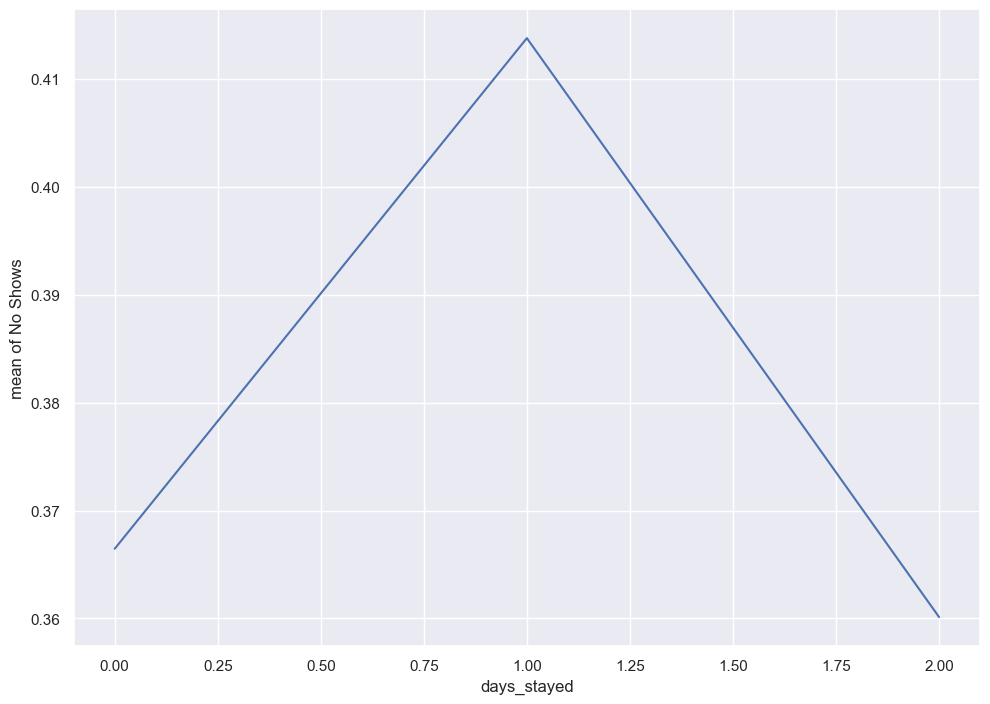

In [139]:
# let's explore if the bins have a linear relationship
# with the target: we see they don't
pd.concat([X_train_efd_enc, y_train], axis=1).groupby('days_stayed')['no_show'].mean().plot()
plt.ylabel('mean of No Shows')

Text(0, 0.5, 'Mean of No Show')

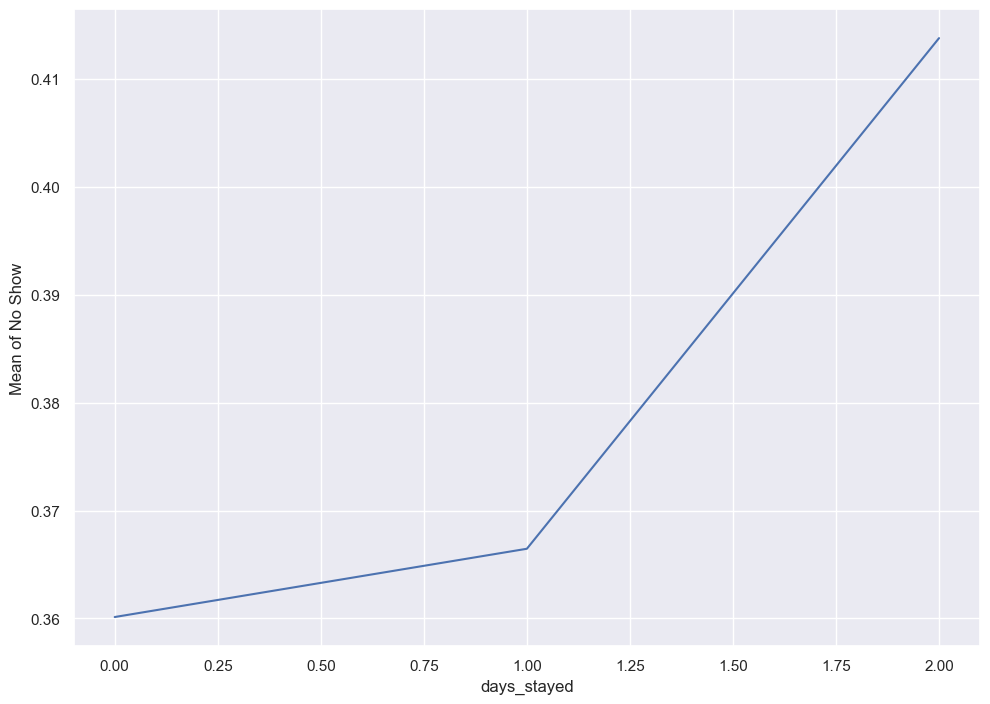

In [140]:
# Task 3: Order the bins to obtain the monotonic relationship between bins and target
ord_enc = OrdinalEncoder(encoding_method = 'ordered')
ord_enc.fit(X_train_efd_enc, y_train)

# let's transformt the data sets
X_train_ord_enc = ord_enc.transform(X_train_efd_enc)
X_test_ord_enc = ord_enc.transform(X_test_efd_enc)

# let's explore the monotonic relationship between bins and target
pd.concat([X_train_ord_enc, y_train], axis=1).groupby('days_stayed')['no_show'].mean().plot()
plt.ylabel('Mean of No Show')

## Handling outliers

In [141]:
out_num_cols = doGetNumericalCols(X_train_ord_enc)

In [142]:
out_cat_cols = doGetCatCols(X_train_ord_enc)

In [143]:
out_num_cols

['booking_month',
 'arrival_month',
 'arrival_day',
 'checkout_month',
 'checkout_day',
 'country',
 'room',
 'price',
 'platform',
 'num_adults',
 'num_children',
 'checkout',
 'checkin',
 'days_stayed',
 'branch_Changi',
 'branch_Orchard',
 'first_time_Yes',
 'first_time_No',
 'currency_SGD$',
 'currency_USD$']

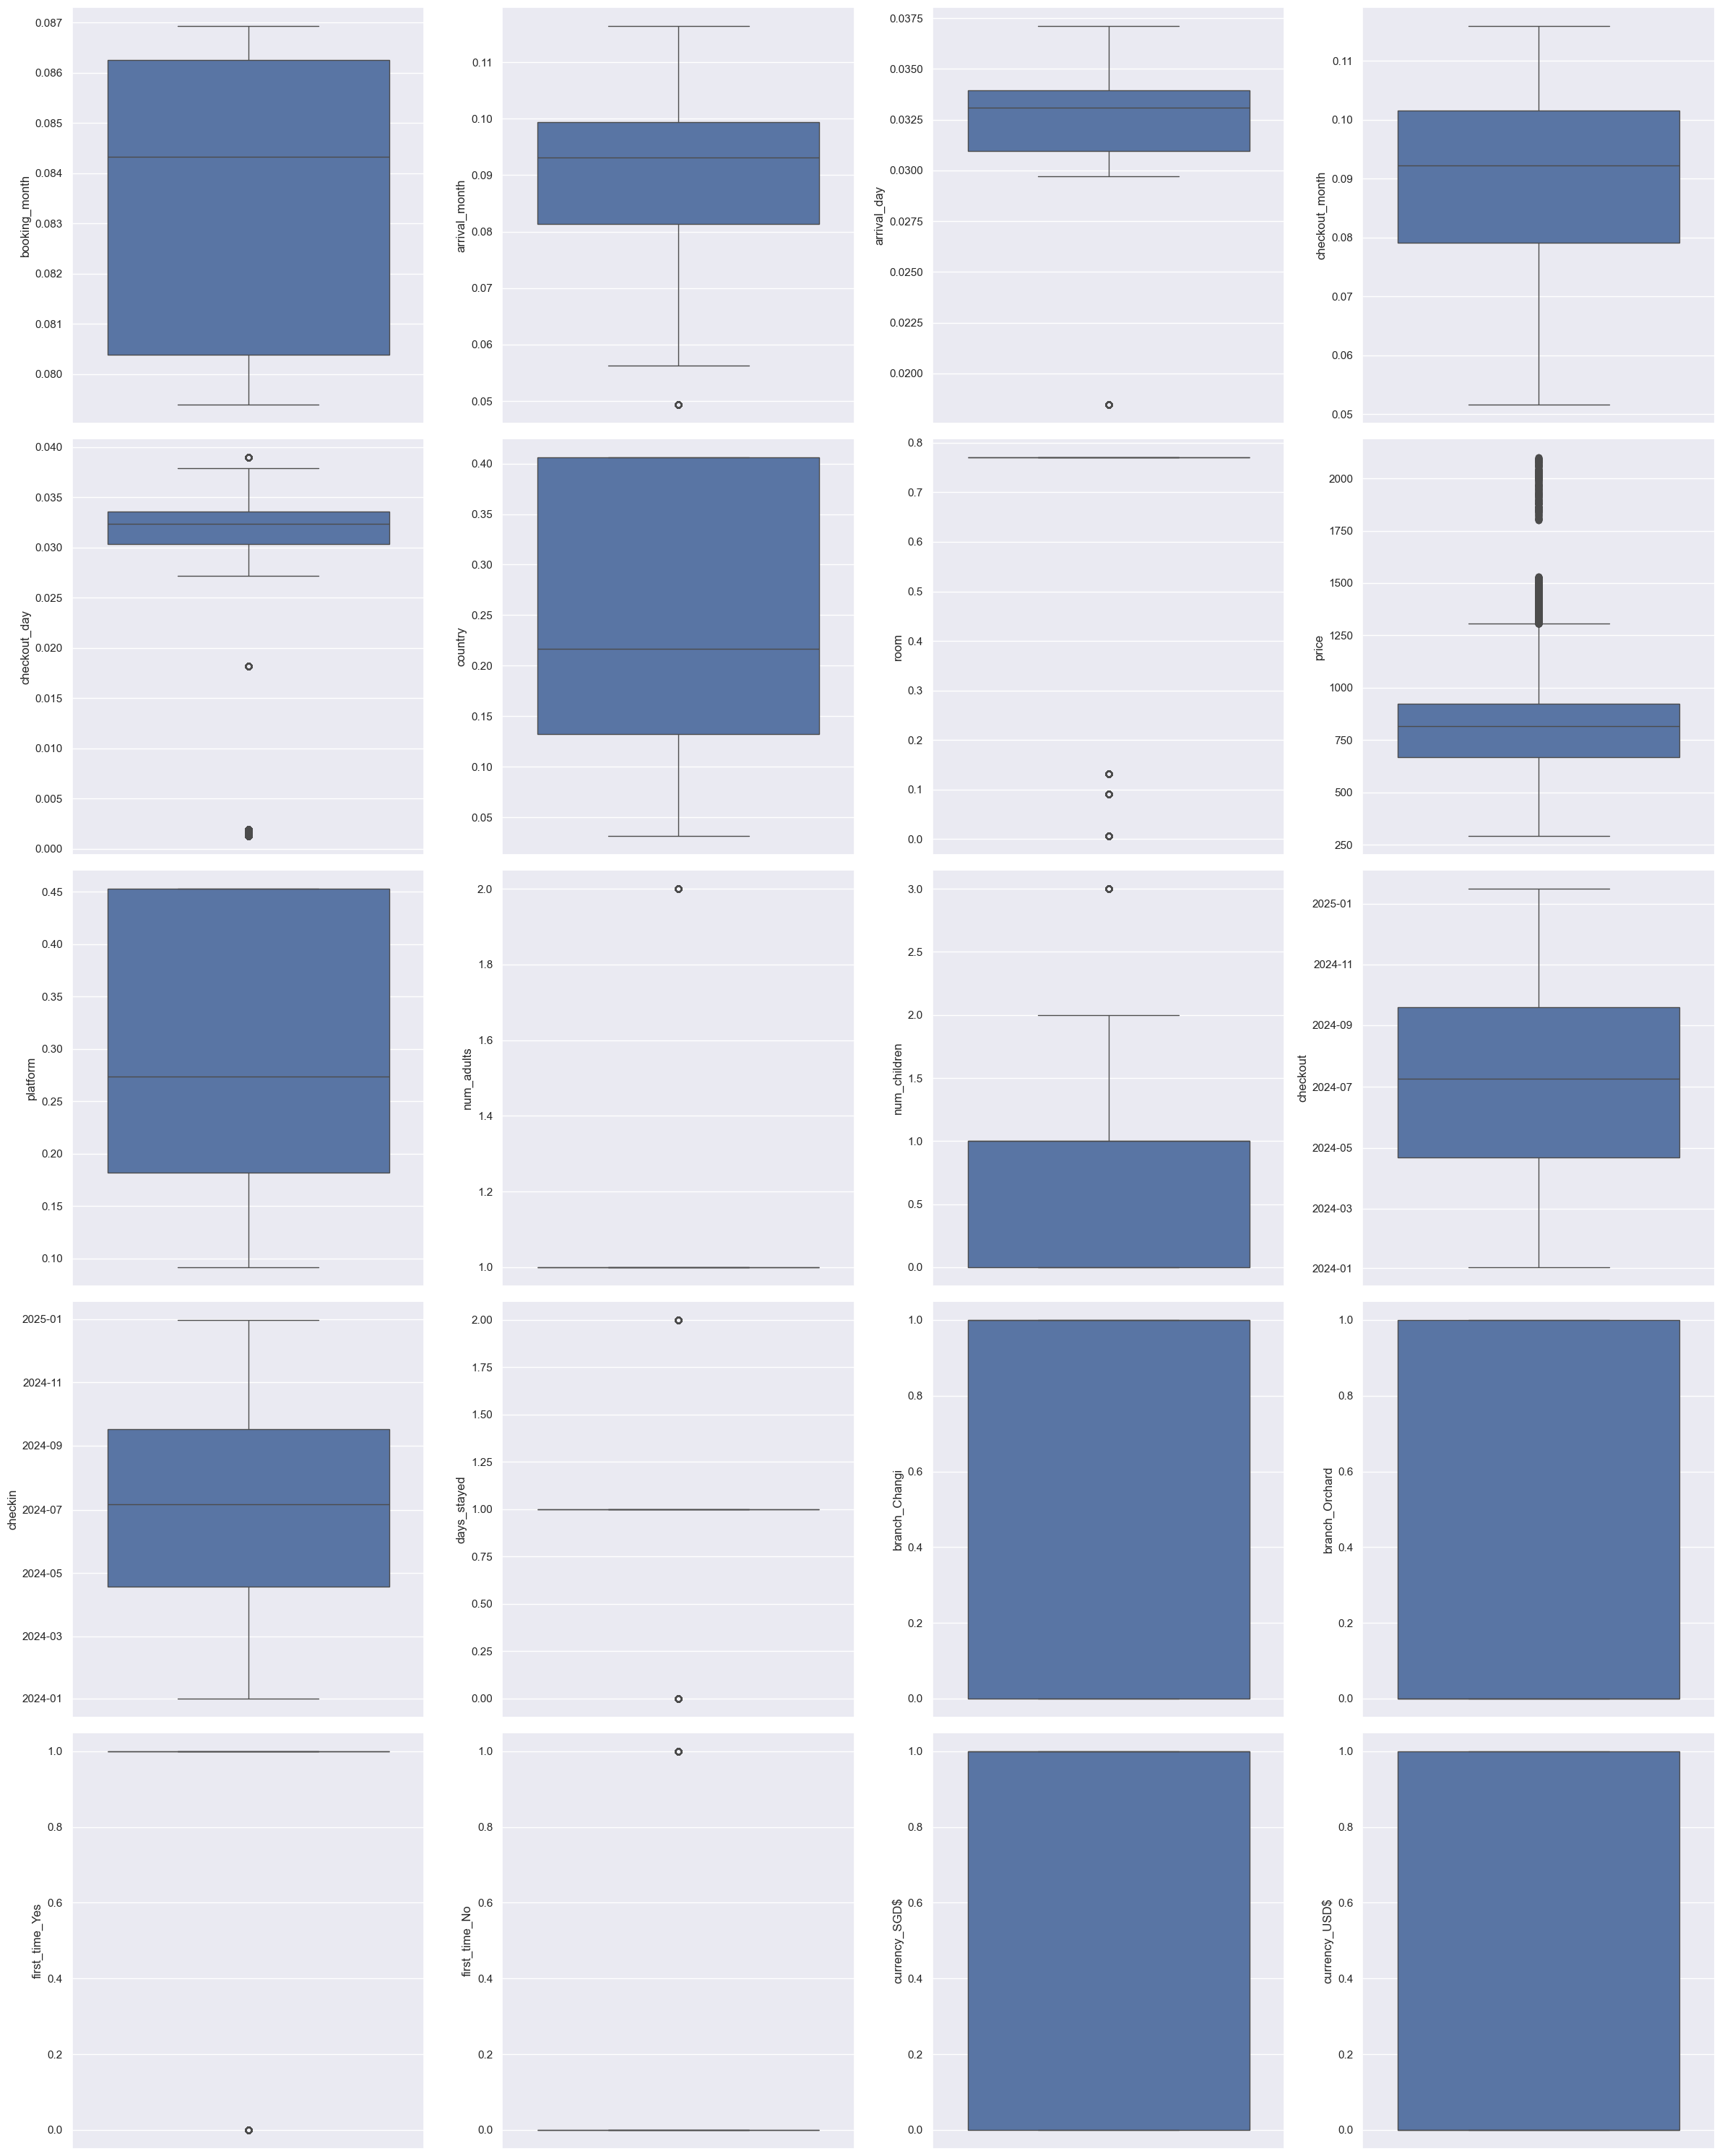

In [144]:
doBoxPlots(X_train_ord_enc, out_num_cols, 'u', None)

## Scaling

In [145]:
sscaler = StandardScaler()
sscaler.fit(X_train_ord_enc.drop(['checkin', 'checkout'], axis=1))

X_train_sscaled = sscaler.transform(X_train_ord_enc.drop(['checkin', 'checkout'], axis=1))
X_test_sscaled =  sscaler.transform(X_test_ord_enc.drop(['checkin', 'checkout'], axis=1))

In [146]:
display (X_train_sscaled.shape)
display (X_test_sscaled.shape)

(83573, 18)

(35817, 18)

# Machine Learning Modelling

In [147]:
from sklearn.linear_model import LogisticRegression

# Simple Logistic Regression with refined features
lr1 = LogisticRegression(max_iter=10000, random_state=42) # Balanced helps with rare HOF cases
lr1.fit(X_train_sscaled, y_train)
y_pred_refined_1 = lr1.predict(X_test_sscaled)

# Calculate the train accuracy of lg - Base
train_acc_1 = lr1.score(X_train_sscaled, y_train)
print("Training Accuracy: %.2f%%" % (train_acc_1*100.0))
# Calculate the testing accuracy of lg - Base
test_acc_1 = lr1.score(X_test_sscaled, y_test)
print("Testing Accuracy: %.2f%%" % (test_acc_1*100.0))

Training Accuracy: 71.13%
Testing Accuracy: 71.48%


In [148]:
# Simple Logistic Regression with refined features
lr2 = LogisticRegression(class_weight = 'balanced', max_iter=10000, random_state=42) # Balanced helps with rare HOF cases
lr2.fit(X_train_sscaled, y_train)
y_pred_lr2 = lr2.predict(X_test_sscaled)

# Calculate the train accuracy of lg - Base
train_acc_2 = lr2.score(X_train_sscaled, y_train)
print("Training Accuracy: %.2f%%" % (train_acc_2*100.0))
# Calculate the testing accuracy of lg - Base
test_acc_2 = lr2.score(X_test_sscaled, y_test)
print("Testing Accuracy: %.2f%%" % (test_acc_1*100.0))

Training Accuracy: 66.73%
Testing Accuracy: 71.48%


In [149]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Initialize the SMOTE object
# You can set sampling_strategy='auto' or a float (e.g., 0.5) 
# if you don't want a perfect 50/50 split.
sm = SMOTE(random_state=42)

# 2. Check the distribution BEFORE SMOTE
print(f"Original training dataset shape: {Counter(y_train)}")

# 3. Fit and apply SMOTE to the training data ONLY
# This creates new synthetic rows for the minority class (Hall of Famers)
X_train_res, y_train_res = sm.fit_resample(X_train_sscaled, y_train)

# 4. Check the distribution AFTER SMOTE
print(f"Resampled training dataset shape: {Counter(y_train_res)}")

lr3 = LogisticRegression(max_iter=10000, random_state=42) # Balanced helps with rare HOF cases
lr3.fit(X_train_res, y_train_res)
y_pred_refined_3 = lr3.predict(X_test_sscaled)

# Calculate the train accuracy of lg - Base
train_acc_3 = lr3.score(X_train_sscaled, y_train)
print("Training Accuracy: %.2f%%" % (train_acc_3*100.0))
# Calculate the testing accuracy of lg - Base
test_acc_3 = lr3.score(X_test_sscaled, y_test)
print("Testing Accuracy: %.2f%%" % (test_acc_3*100.0))

Original training dataset shape: Counter({0: 52587, 1: 30986})
Resampled training dataset shape: Counter({0: 52587, 1: 52587})
Training Accuracy: 66.81%
Testing Accuracy: 66.45%


In [150]:
X_train_ord_enc.columns

Index(['booking_month', 'arrival_month', 'arrival_day', 'checkout_month',
       'checkout_day', 'country', 'room', 'price', 'platform', 'num_adults',
       'num_children', 'checkout', 'checkin', 'days_stayed', 'branch_Changi',
       'branch_Orchard', 'first_time_Yes', 'first_time_No', 'currency_SGD$',
       'currency_USD$'],
      dtype='object')

y_test: 30946     0
40207     0
103708    0
85144     1
109991    0
         ..
104051    0
13158     0
72432     1
111986    0
46463     1
Name: no_show, Length: 35817, dtype: int32
predictions: [1 0 1 ... 0 0 0]
Accuracy: 75.07%


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

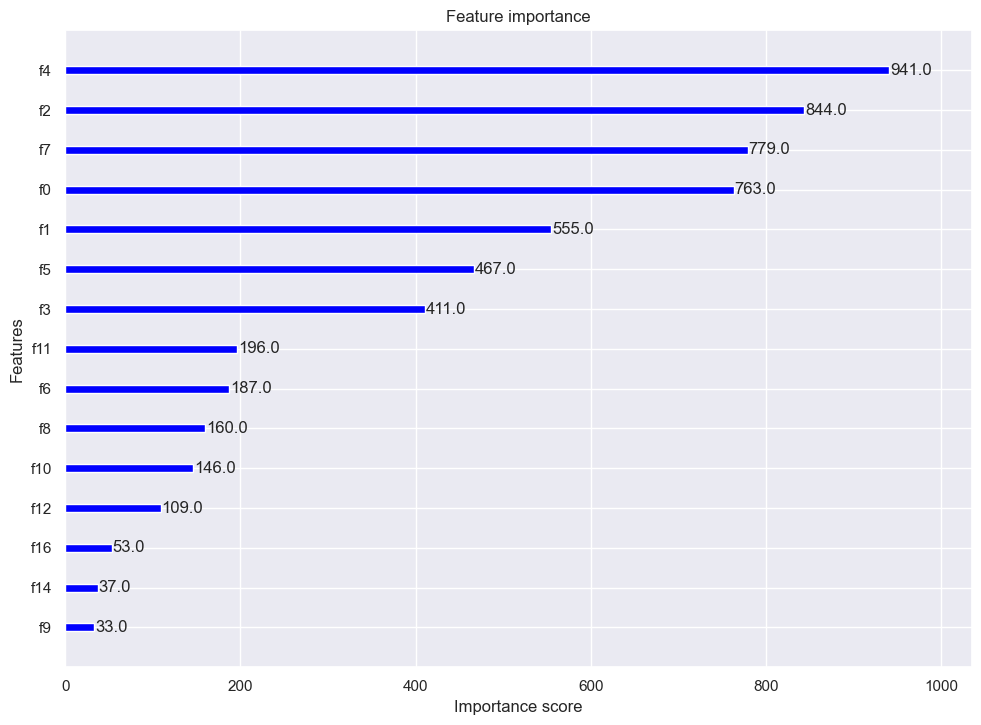

In [151]:
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import accuracy_score 

features_list = [ele for ele in X_train_ord_enc.columns if ele not in ['checkout', 'checkin']]

# Instantiate an XGBoost classifier
xgbc = xgb.XGBClassifier(n_estimators=100, random_state=42)

# Train the model
xgbc.fit(X_train_sscaled, y_train)
# Make predictions
predictions = xgbc.predict(X_test_sscaled)

# XGBoost 3.1.3
# print (xgbc.get_booster().features_list()) # AttributeError: 'Booster' object has no attribute 'features_list'

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print('y_test:', y_test)
print('predictions:', predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

plot_importance(xgbc, color='blue')
# Feature importance
# feature_importance_sorted_idx = xgbc.feature_importances_.argsort()
# features_list = [ele for ele in X_train_ord_enc.columns if ele not in ['checkout', 'checkin']]

# print(features_list)  # Output: [7, 7, 7]
# print (feature_importance_sorted_idx)
# # Plotting feature importance
# # plt.barh(features_list, feature_importance)
# plt.barh(features_list[feature_importance_sorted_idx], xgbc.feature_importances_[feature_importance_sorted_idx])
# plt.xlabel('Feature Importance Score')
# plt.ylabel('Features')
# plt.title('Visualizing Important Features with XGBoost')

In [152]:
# Instantiate an XGBoost classifier
xgbc = xgb.XGBClassifier(n_estimators=100, random_state=42)

# Train the model
xgbc.fit(X_train_sscaled, y_train)
# Make predictions
predictions = xgbc.predict(X_test_sscaled)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print('y_test:', y_test)
print('predictions:', predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

y_test: 30946     0
40207     0
103708    0
85144     1
109991    0
         ..
104051    0
13158     0
72432     1
111986    0
46463     1
Name: no_show, Length: 35817, dtype: int32
predictions: [1 0 1 ... 0 0 0]
Accuracy: 75.07%


In [153]:
# Calculate the train accuracy of lg - Base
train_acc_4 = xgbc.score(X_train_sscaled, y_train)
print("Training Accuracy: %.2f%%" % (train_acc_4*100.0))
# Calculate the testing accuracy of lg - Base
test_acc_4 = xgbc.score(X_test_sscaled, y_test)
print("Testing Accuracy: %.2f%%" % (test_acc_4*100.0))

Training Accuracy: 78.37%
Testing Accuracy: 75.07%


In [154]:
def doPlotFeatureImportanceRFC(X_train, y_train, columns, model):
    # Initialize and train the model
    # rf = RandomForestClassifier(n_estimators=100, random_state=42) # Use 100s or 1000s of trees for better results
    model.fit(X_train, y_train)
    
    # Get the feature importances and sort them
    importances = model.feature_importances_
    feature_importances_series = pd.Series(importances, index=columns)
    
    sorted_feature_importances = feature_importances_series.sort_values(ascending=False)

    plt.figure(figsize=(10,5))
    sns.barplot(x=sorted_feature_importances, y=sorted_feature_importances.index, hue=sorted_feature_importances.index, palette='bright')

    plt.title("Sorted Feature Importances")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Names")

    plt.tight_layout()
    plt.show()
    
# doPlotFeatureImportanceRFC(X_train_dtc, y_train_dtc, X_train_dtc.columns, rfc)

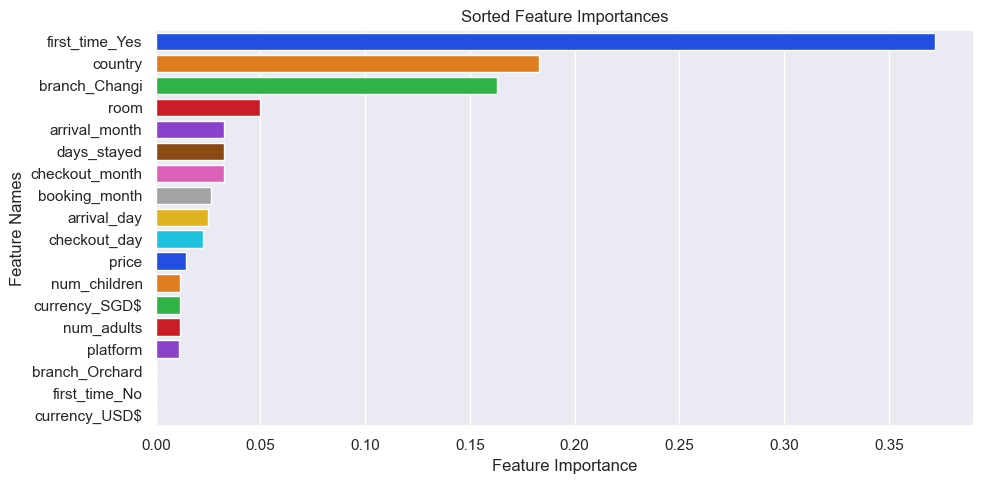

In [155]:
doPlotFeatureImportanceRFC(X_train_sscaled, y_train, features_list, xgbc)

In [156]:
y_train_xgbc_pl_pred = xgbc.predict(X_train_sscaled)
y_train_xgbc_pl_pred_proba = xgbc.predict_proba(X_train_sscaled)[:, 1]

y_test_xgbc_pl_pred = xgbc.predict(X_test_sscaled)
y_test_xgbc_pl_pred_proba = xgbc.predict_proba(X_test_sscaled)[:, 1]

<Figure size 800x600 with 0 Axes>

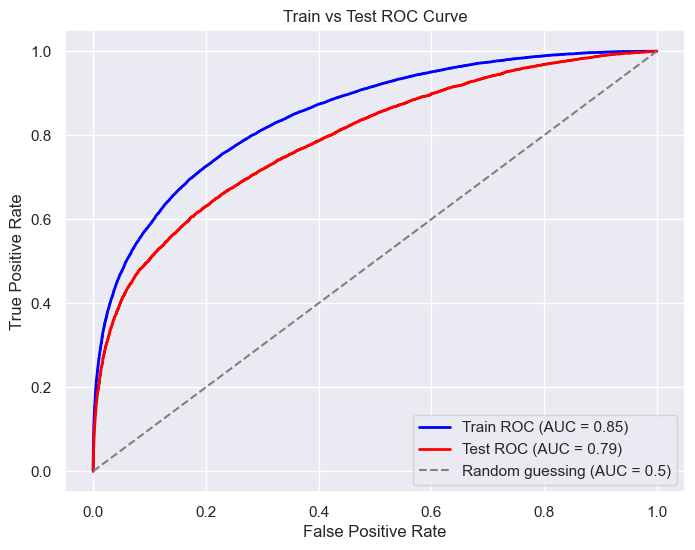

In [157]:
doPlotTrainTestROCCurve(y_train, y_train_xgbc_pl_pred_proba, y_test, y_test_xgbc_pl_pred_proba)

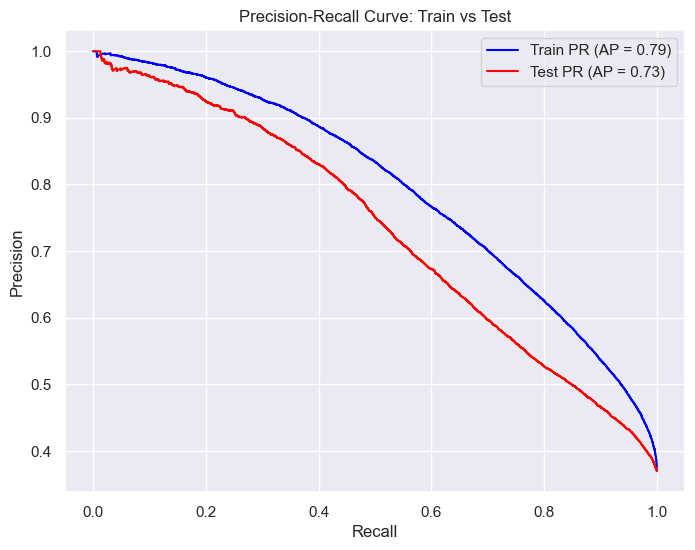

In [158]:
doPlotPrecisioRecall(y_train, y_train_xgbc_pl_pred_proba, y_test, y_test_xgbc_pl_pred_proba)

In [159]:
xgbc_param_grid = {  
    # prefix with 'classifier__' if using pipeline
    # "classifier__n_estimators": [50, 100, 200], 
    # "classifier__learning_rate": [0.1, 0.01, 0.05], 
    # "classifier__max_depth": [3, 5, 7]
    'learning_rate': [0.01, 0.1, 0.2], 
    'max_depth': [3, 5, 7], 
    'n_estimators': [100, 200, 300]    
    }

# Cross-validation on train set
clf_scoring = {"acc": "accuracy"}

# cv: number of partitions for cross validation
# n_jobs: number of jobs to run in parallel, -1 means using all processors
xgbc_gs = GridSearchCV(xgbc, param_grid = xgbc_param_grid, scoring = clf_scoring, refit = 'acc', cv = 5, n_jobs= -1, return_train_score=True)

xgbc_gs.fit(X_train_sscaled, y_train) 

print(f"XGBoost GS Best Score: {xgbc_gs.best_score_:.4f}")
print(f"XGBoost GS Best Parameters: {xgbc_gs.best_params_}")

xgbc_gs_best_model =  xgbc_gs.best_estimator_
print("XGBoost GS Best Model:", {xgbc_gs_best_model})

XGBoost GS Best Score: 0.7526
XGBoost GS Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
XGBoost GS Best Model: {XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)}


In [160]:
xgbc_gs_cv_results = xgbc_gs.cv_results_
# Convert to dataframe
xgbc_gs_cv_df = pd.DataFrame(xgbc_gs_cv_results)
xgbc_gs_cv_df.columns

print(f"XGBoost GS CV Train Accuracy: {xgbc_gs_cv_results['mean_train_acc'].mean():.4f}")
print(f"XGBoost GS CV Test Accuracy: {xgbc_gs_cv_results['mean_test_acc'].mean():.4f}")

print(f"XGBoost (Score) Train Accuracy: {xgbc_gs.score(X_train_sscaled, y_train):.4f}", )
print(f"XGBoost (Score) Test Accuracy: {xgbc_gs.score(X_test_sscaled, y_test):.4f}")

XGBoost GS CV Train Accuracy: 0.7555
XGBoost GS CV Test Accuracy: 0.7351
XGBoost (Score) Train Accuracy: 0.8107
XGBoost (Score) Test Accuracy: 0.7578


In [161]:
y_train_xgbc_gs_pred = xgbc_gs.predict(X_train_sscaled)
y_train_xgbc_gs_pred_proba = xgbc_gs.predict_proba(X_train_sscaled)[:, 1]

y_test_xgbc_gs_pred = xgbc_gs.predict(X_test_sscaled)
y_test_xgbc_gs_pred_proba = xgbc_gs.predict_proba(X_test_sscaled)[:, 1]

<Figure size 800x600 with 0 Axes>

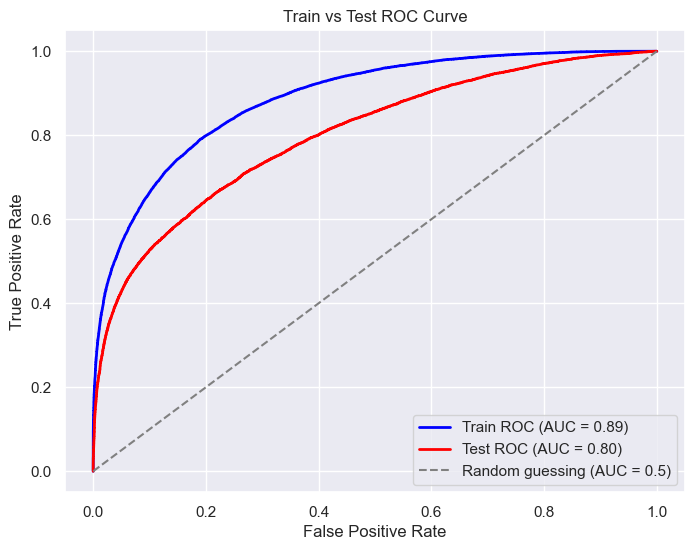

In [162]:
doPlotTrainTestROCCurve(y_train, y_train_xgbc_gs_pred_proba, y_test, y_test_xgbc_gs_pred_proba)

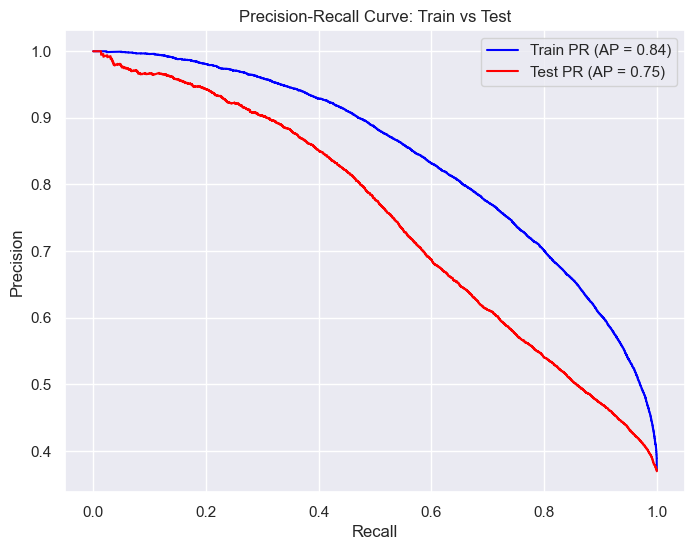

In [163]:
doPlotPrecisioRecall(y_train, y_train_xgbc_gs_pred_proba, y_test, y_test_xgbc_gs_pred_proba)

XGBoost GS Best Model Train Accuracy: 0.8107
XGBoost GS Best Model Test Accuracy: 0.7578


<Figure size 800x600 with 0 Axes>

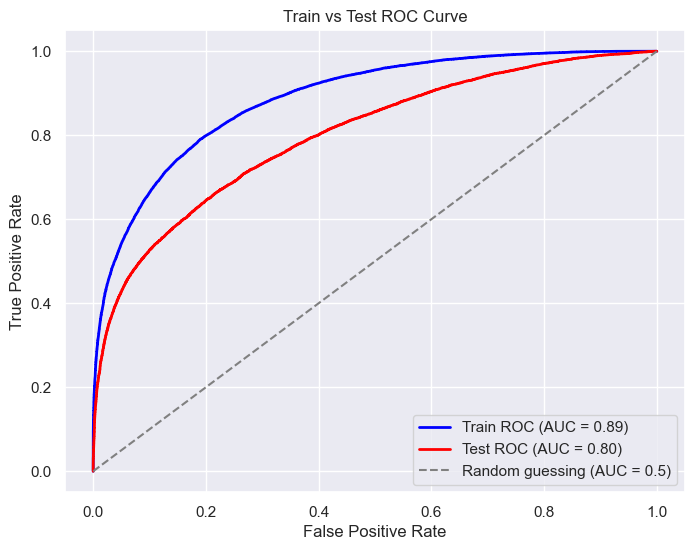

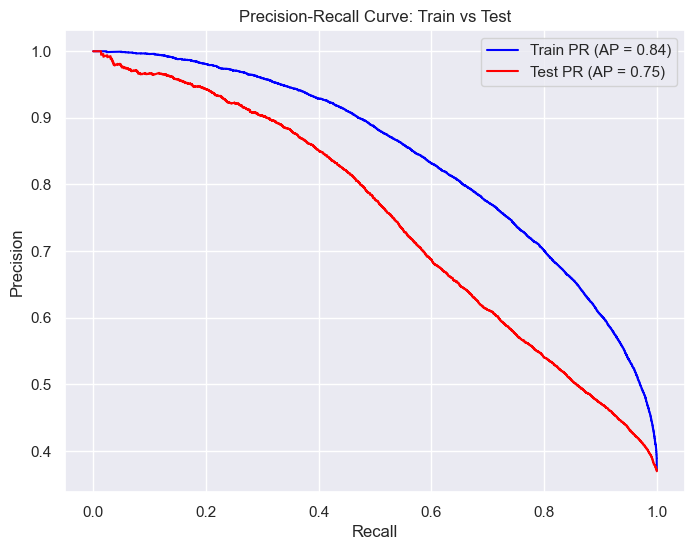

In [164]:
print (f"XGBoost GS Best Model Train Accuracy: {xgbc_gs_best_model.score(X_train_sscaled, y_train):.4f}")
print (f"XGBoost GS Best Model Test Accuracy: {xgbc_gs_best_model.score(X_test_sscaled, y_test):.4f}")

y_train_xgbc_gs_best_pred = xgbc_gs_best_model.predict(X_train_sscaled)
y_train_xgbc_gs_best_pred_proba = xgbc_gs_best_model.predict_proba(X_train_sscaled)[:, 1]

y_test_xgbc_gs_best_pred = xgbc_gs_best_model.predict(X_test_sscaled)
y_test_xgbc_gs_best_pred_proba = xgbc_gs_best_model.predict_proba(X_test_sscaled)[:, 1]

doPlotTrainTestROCCurve(y_train, y_train_xgbc_gs_best_pred_proba, y_test, y_test_xgbc_gs_best_pred_proba)
doPlotPrecisioRecall(y_train, y_train_xgbc_gs_best_pred_proba, y_test, y_test_xgbc_gs_best_pred_proba)

y_test: 30946     0
40207     0
103708    0
85144     1
109991    0
         ..
104051    0
13158     0
72432     1
111986    0
46463     1
Name: no_show, Length: 35817, dtype: int32
predictions: [1 0 1 ... 0 0 0]
Accuracy: 75.07%


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

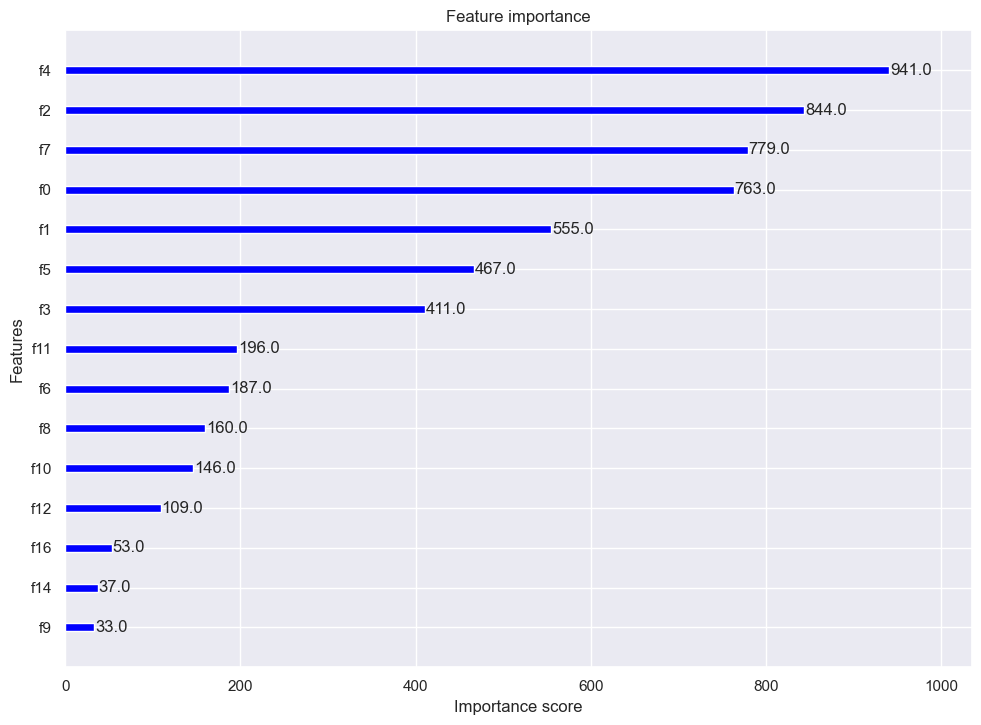

In [165]:
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import accuracy_score 

features_list = [ele for ele in X_train_ord_enc.columns if ele not in ['checkout', 'checkin']]

# Instantiate an XGBoost classifier
xgbc = xgb.XGBClassifier(n_estimators=100, random_state=42)

# Train the model
xgbc.fit(X_train_sscaled, y_train)
# Make predictions
predictions = xgbc.predict(X_test_sscaled)

# XGBoost 3.1.3
# print (xgbc.get_booster().features_list()) # AttributeError: 'Booster' object has no attribute 'features_list'

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print('y_test:', y_test)
print('predictions:', predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

plot_importance(xgbc, color='blue')
# Feature importance
# feature_importance_sorted_idx = xgbc.feature_importances_.argsort()
# features_list = [ele for ele in X_train_ord_enc.columns if ele not in ['checkout', 'checkin']]

# print(features_list)  # Output: [7, 7, 7]
# print (feature_importance_sorted_idx)
# # Plotting feature importance
# # plt.barh(features_list, feature_importance)
# plt.barh(features_list[feature_importance_sorted_idx], xgbc.feature_importances_[feature_importance_sorted_idx])
# plt.xlabel('Feature Importance Score')
# plt.ylabel('Features')
# plt.title('Visualizing Important Features with XGBoost')

In [166]:
xgb.__version__

'3.1.3'

In [167]:
# Calculate the train accuracy of lg - Base
train_acc_4 = xgbc.score(X_train_sscaled, y_train)
print("Training Accuracy: %.2f%%" % (train_acc_4*100.0))
# Calculate the testing accuracy of lg - Base
test_acc_4 = xgbc.score(X_test_sscaled, y_test)
print("Testing Accuracy: %.2f%%" % (test_acc_4*100.0))

Training Accuracy: 78.37%
Testing Accuracy: 75.07%


In [168]:
import pandas as pd
import datetime

def calculate_duration_ignore_year(start_date, end_date):
    # Standardize the year to a common leap year (e.g., 2020)
    # Extract month and day
    try:
        start_md = start_date.replace(year=2020)
        end_md = end_date.replace(year=2020)
    except ValueError:
        # Handle cases where original day is invalid in Feb (e.g., Feb 30) - this should ideally be cleaned beforehand
        return pd.NaT 

    # Calculate difference. If end date is 'before' start date in the calendar year, assume it's the next year in sequence.
    if end_md < start_md:
        end_md = end_md.replace(year=2021) # Increment year to calculate duration correctly across year boundary

    duration = abs((end_md - start_md).days)
    return duration

In [169]:
df_noshow.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119390 entries, 0 to 119390
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   booking_id      119390 non-null  int64         
 1   no_show         119390 non-null  int32         
 2   branch          119390 non-null  object        
 3   booking_month   119390 non-null  object        
 4   arrival_month   119390 non-null  object        
 5   arrival_day     119390 non-null  object        
 6   checkout_month  119390 non-null  object        
 7   checkout_day    119390 non-null  object        
 8   country         119390 non-null  object        
 9   first_time      119390 non-null  object        
 10  room            97778 non-null   object        
 11  price           94509 non-null   float64       
 12  platform        119390 non-null  object        
 13  num_adults      11402 non-null   float64       
 14  num_children    119390 non-null  float64 

In [170]:
# Apply the function to calculate duration
# df['duration_days'] = df.apply(lambda row: calculate_duration_ignore_year(row['start_date'], row['end_date']), axis=1)

# print(df[['start_date', 'end_date', 'duration_days']])

df_noshow['duration_days'] = df_noshow.apply(lambda row: calculate_duration_ignore_year(row['checkin'], row['checkout']), axis=1)

print(df_noshow[['checkin', 'checkout', 'duration_days']])

          checkin   checkout  duration_days
0      2024-06-25 2024-06-27              2
1      2024-11-28 2024-11-29              1
2      2024-02-07 2024-02-11              4
3      2024-10-01 2024-10-03              2
4      2024-06-20 2024-06-24              4
...           ...        ...            ...
119386 2024-04-03 2024-04-05              2
119387 2024-12-30 2025-01-03              4
119388 2024-03-31 2024-04-01              1
119389 2024-02-25 2024-02-27              2
119390 2024-07-18 2024-07-26              8

[119390 rows x 3 columns]


In [171]:
df_noshow['duration'] = df_noshow['checkout'] - df_noshow['checkin']

In [172]:
display (df_noshow)

,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,...,price,platform,num_adults,num_children,currency,checkout,checkin,days_stayed,duration_days,duration
0,94113,0,Changi,November,June,25,June,27,Singapore,Yes,...,492.98,Website,NaN,0.0,SGD$,2024-06-27,2024-06-25,2,2,2 days
1,86543,0,Orchard,August,November,28,November,29,Indonesia,Yes,...,1351.22,Website,NaN,0.0,SGD$,2024-11-29,2024-11-28,1,1,1 days
2,75928,0,Changi,March,February,07,February,11,India,Yes,...,NaN,Agent,NaN,0.0,None,2024-02-11,2024-02-07,4,4,4 days
3,66947,1,Orchard,September,October,01,October,03,China,Yes,...,666.04,Website,NaN,0.0,SGD$,2024-10-03,2024-10-01,2,2,2 days
4,106390,0,Orchard,March,June,20,June,24,Australia,Yes,...,665.37,Website,NaN,0.0,USD$,2024-06-24,2024-06-20,4,4,4 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119386,4823,0,Changi,September,April,03,April,05,China,Yes,...,612.18,Website,NaN,1.0,USD$,2024-04-05,2024-04-03,2,2,2 days
119387,25062,0,Orchard,March,December,30,January,03,China,Yes,...,1041.29,Email,NaN,0.0,USD$,2025-01-03,2024-12-30,4,4,4 days
119388,81936,1,Changi,September,March,31,April,01,Indonesia,Yes,...,641.47,Email,NaN,2.0,USD$,2024-04-01,2024-03-31,1,1,1 days
119389,6738,0,Changi,February,February,25,February,27,China,Yes,...,886.35,Website,NaN,0.0,SGD$,2024-02-27,2024-02-25,2,2,2 days


## Deep Learning

In [173]:
def doCheckGPU():
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    return (device)

In [174]:
print (doCheckGPU())

cuda:0


In [175]:
# Configuration
epochs = 30              
batch_size = 32          
learning_rate = 0.01
momentum = 0.9

In [180]:
n_inputs = X_train.shape[1] # number of features
print (n_inputs)

17


In [199]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset, DataLoader

# dataset definition
class TabularDataset(Dataset):
    # load the dataset
    def __init__(self, X,y):
        # store the inputs and outputs
        self.X = X
        self.y = y
 
    # number of rows in the dataset
    def __len__(self):
        return len(self.X)
 
    # get a row at an index
    def __getitem__(self, idx):
        return [self.X[idx], self.y[idx]]

In [190]:
train_dataset = TabularDataset(X_train_sscaled,y_train)
# val_dataset = TabularDataset(X_val,y_val)
test_dataset = TabularDataset(X_test_sscaled,y_test)

# train_set_size = int(len(dataset) * 0.8) # we can split the data to train - test - validation like this too. But not doing that here
# valid_set_size = len(dataset) - train_set_size
# train_set, valid_set = data.random_split(dataset, [train_set_size, valid_set_size])

train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_dl = DataLoader(val_dataset, batch_size=X_val.shape[0], shuffle=False) # we will load entire validation set as a batch
test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) #  will load entire test set as a batch

In [205]:
# type (y_train)
y_train.unique()
y_test.unique()

array([0, 1])

In [200]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_sscaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)

X_test_tensor = torch.tensor(X_test_sscaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

# Wrap in TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [206]:
class NeuralNetwork(nn.Module):
    
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features=input_dim, out_features=hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(in_features=hidden_dim * 2, out_features=hidden_dim * 4),
            nn.ReLU(),
            nn.Linear(in_features=hidden_dim * 4, out_features=hidden_dim * 8),
            nn.ReLU(),
            nn.Linear(in_features=hidden_dim * 8, out_features=2)
        )
        
    def forward(self, x):
        return self.network(x)

In [207]:
# Instantiate the NeuralNetwork class
model = NeuralNetwork(input_dim=X_train_sscaled.shape[1], hidden_dim=8)
model

NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [208]:
criterion = nn.CrossEntropyLoss()   # good for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [212]:
num_epochs = 50
model.train()
for epoch in range(num_epochs):
    
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        total_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/50, Loss: 0.5275
Epoch 2/50, Loss: 0.5269
Epoch 3/50, Loss: 0.5272
Epoch 4/50, Loss: 0.5266
Epoch 5/50, Loss: 0.5267
Epoch 6/50, Loss: 0.5259
Epoch 7/50, Loss: 0.5259
Epoch 8/50, Loss: 0.5256
Epoch 9/50, Loss: 0.5253
Epoch 10/50, Loss: 0.5246
Epoch 11/50, Loss: 0.5251
Epoch 12/50, Loss: 0.5246
Epoch 13/50, Loss: 0.5241
Epoch 14/50, Loss: 0.5241
Epoch 15/50, Loss: 0.5238
Epoch 16/50, Loss: 0.5237
Epoch 17/50, Loss: 0.5232
Epoch 18/50, Loss: 0.5229
Epoch 19/50, Loss: 0.5226
Epoch 20/50, Loss: 0.5229
Epoch 21/50, Loss: 0.5220
Epoch 22/50, Loss: 0.5222
Epoch 23/50, Loss: 0.5216
Epoch 24/50, Loss: 0.5217
Epoch 25/50, Loss: 0.5215
Epoch 26/50, Loss: 0.5210
Epoch 27/50, Loss: 0.5209
Epoch 28/50, Loss: 0.5206
Epoch 29/50, Loss: 0.5209
Epoch 30/50, Loss: 0.5201
Epoch 31/50, Loss: 0.5205
Epoch 32/50, Loss: 0.5199
Epoch 33/50, Loss: 0.5198
Epoch 34/50, Loss: 0.5196
Epoch 35/50, Loss: 0.5192
Epoch 36/50, Loss: 0.5189
Epoch 37/50, Loss: 0.5192
Epoch 38/50, Loss: 0.5186
Epoch 39/50, Loss: 0.

In [211]:
from sklearn.metrics import precision_score, recall_score, f1_score

model.eval()
correct, total = 0, 0
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        
        # Collect predictions and labels for metrics
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Accuracy
accuracy = 100 * correct / total

# Precision, Recall, F1
precision = precision_score(all_labels, all_preds, average="binary")
recall = recall_score(all_labels, all_preds, average="binary")
f1 = f1_score(all_labels, all_preds, average="binary")

print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

Test Accuracy: 73.28%
Precision: 0.675
Recall: 0.534
F1 Score: 0.596


In [ ]:
df_noshow['arrival'] = str(df_noshow['arrival_day']) + ' ' + df_noshow['arrival_month']

In [ ]:
df_noshow['arrival'] = pd.to_datetime(
    df_noshow['arrival_day'] + ' ' + df_noshow['arrival_month'] + ' 2024',
    format='%d %B %Y'
)

In [ ]:
display (df_noshow['arrival'])

In [ ]:
df_noshow['checkout'] = pd.to_datetime(
    df_noshow['checkout_day'] + ' ' + df_noshow['checkout_month'] + ' 2024',
    format='%d %B %Y'
)

In [ ]:
df_noshow['checkout_day']

In [ ]:
# Combine using np.where
df_noshow['arrival_X'] = np.where(
    df_noshow['arrival_month'].isnull() & df_noshow['arrival_day'].isnull(),  # both null
    np.nan,
    np.where(
        df_noshow['arrival_month'].isnull(), df_noshow['arrival_day'],  # col1 null → take col2
        np.where(
            df_noshow['arrival_day'].isnull(), df_noshow['arrival_month'],  # col2 null → take col1
            df_noshow['arrival_month'] + ' ' + str(df_noshow['arrival_day']) # both non-null → take col1 (or col2 if you prefer)
        )
    )
)

In [ ]:
df_noshow['arrival_X']

In [ ]:
df_noshow['arrival'] = df_noshow['arrival_month'] + ' ' + str(df_noshow['arrival_day'])

In [ ]:
df_noshow['checkout'] = df_noshow['checkout_month'] + ' ' + str(df_noshow['checkout_day'])

In [ ]:
df_noshow.isnull().sum()

In [ ]:
# Ref: https://stackoverflow.com/questions/21287624/convert-pandas-column-containing-nans-to-dtype-int
# To combine integers and NaNs in a column, you can use the 'object' data type:
# This will replace NaNs with an integer (doesn't matter which), convert to int, convert to object and finally reinsert NaNs.
df_noshow['checkout_day'] = (
    df_noshow['checkout_day'].fillna(0)
    .astype(int)
    .astype(object)
    .where(df_noshow['checkout_day'].notnull())
)

df_noshow['arrival_day'] = (
    df_noshow['arrival_day'].fillna(0)
    .astype(int)
    .astype(object)
    .where(df_noshow['arrival_day'].notnull())
)

df_noshow['no_show'] = (
    df_noshow['no_show'].fillna(0)
    .astype(int)
    .astype(object)
    .where(df_noshow['no_show'].notnull())
)

In [ ]:
df_noshow['num_children'] = (
    df_noshow['num_children'].fillna(0)
    .astype(int)
    .astype(object)
    .where(df_noshow['num_children'].notnull())
)

In [ ]:
# Convert invalid entries to NaN, then use nullable integers
df_noshow['num_adults'] = pd.to_numeric(df_noshow['num_adults'], errors='coerce').astype('Int64')

In [ ]:
df_noshow.isnull().sum()

In [ ]:
# Convert the 'MonthString' column to datetime objects
# '%b' matches abbreviated month names (Jan, Feb, etc.)
# Note: Pandas automatically assigns the 1st day of the current year if day/year are not specified.
df_noshow['booking_month'] = pd.to_datetime(df_noshow['booking_month'], format='mixed', errors="coerce")
df_noshow['arrival_month'] = pd.to_datetime(df_noshow['arrival_month'], format='mixed', errors="coerce")
df_noshow['checkout_month'] = pd.to_datetime(df_noshow['checkout_month'], format='mixed', errors="coerce")

In [ ]:
df_noshow